<a href="https://colab.research.google.com/github/abhishekanand04/ML-Unsupervised-and-RecSys/blob/unsupervised/Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (20, 6)

In [ ]:
plt.rcParams['figure.figsize'] = (20, 6)  # Again because some issue with google colab

In [ ]:
!gdown 1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg

Downloading...
From: https://drive.google.com/uc?id=1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg
To: /content/mobilesales.xlsx
100% 13.7k/13.7k [00:00<00:00, 41.7MB/s]


In [ ]:
mobile_sales = pd.read_excel('/content/mobilesales.xlsx')
mobile_sales.head()

,DATE,Sales
0,2001-01-01,6519.0
1,2001-02-01,6654.0
2,2001-03-01,7332.0
3,2001-04-01,7332.0
4,2001-05-01,8240.0


In [ ]:
mobile_sales.set_index('DATE', inplace=True)
mobile_sales

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0
...,...
2018-09-01,13838.0
2018-10-01,15351.0
2018-11-01,15615.0


<Axes: xlabel='DATE'>

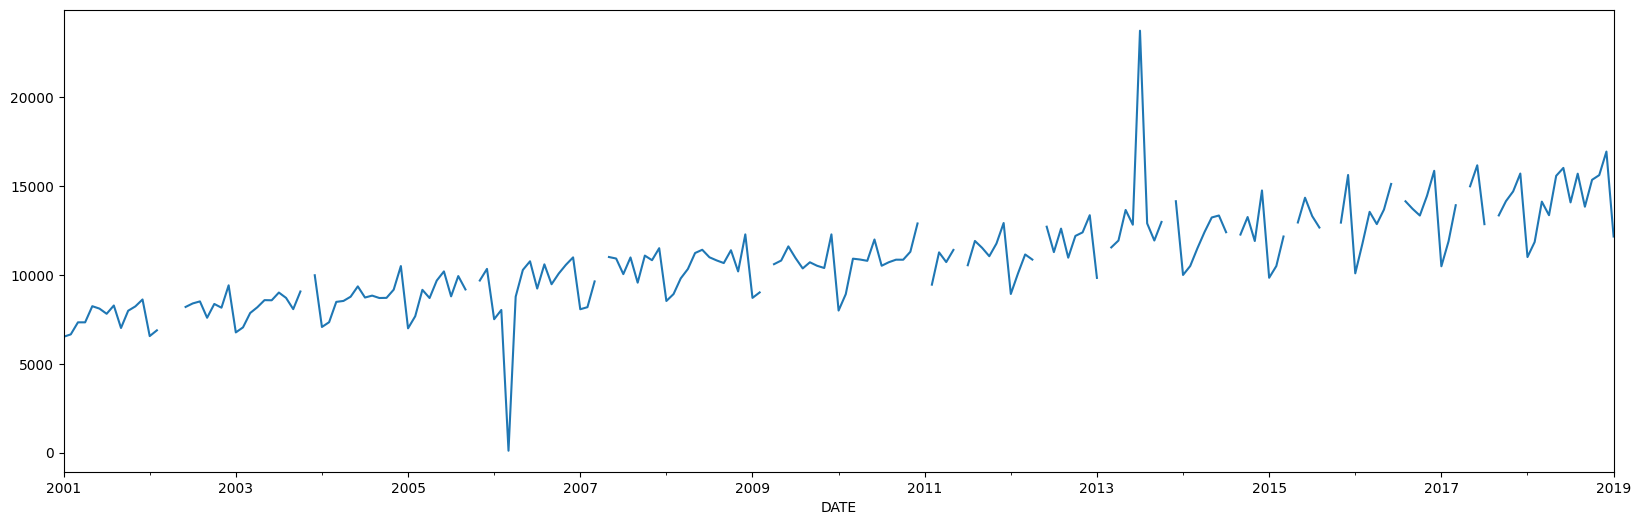

In [ ]:
mobile_sales.Sales.plot()

In [ ]:
mobile_sales.Sales = mobile_sales.Sales.interpolate(method='linear')

In [ ]:
mobile_sales.Sales = mobile_sales.Sales.clip(upper=mobile_sales.Sales.quantile(0.98), lower=mobile_sales.Sales.quantile(0.02))

<Axes: xlabel='DATE'>

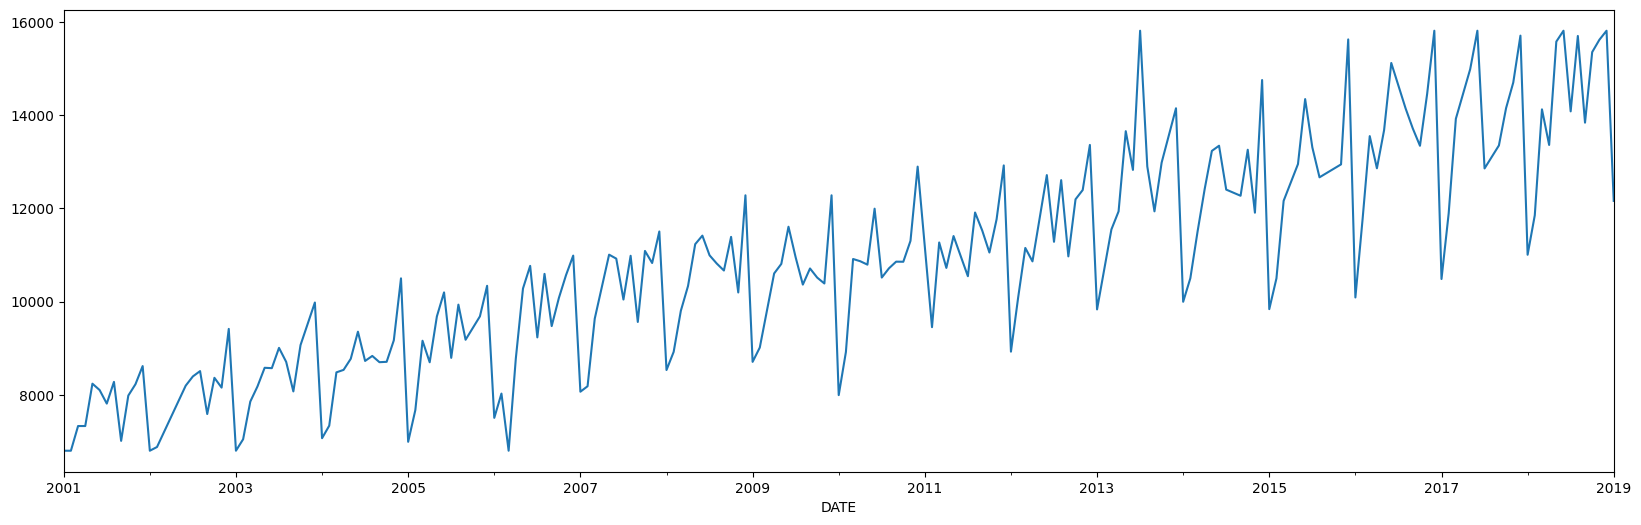

In [ ]:
mobile_sales.Sales.plot()

<Axes: xlabel='DATE'>

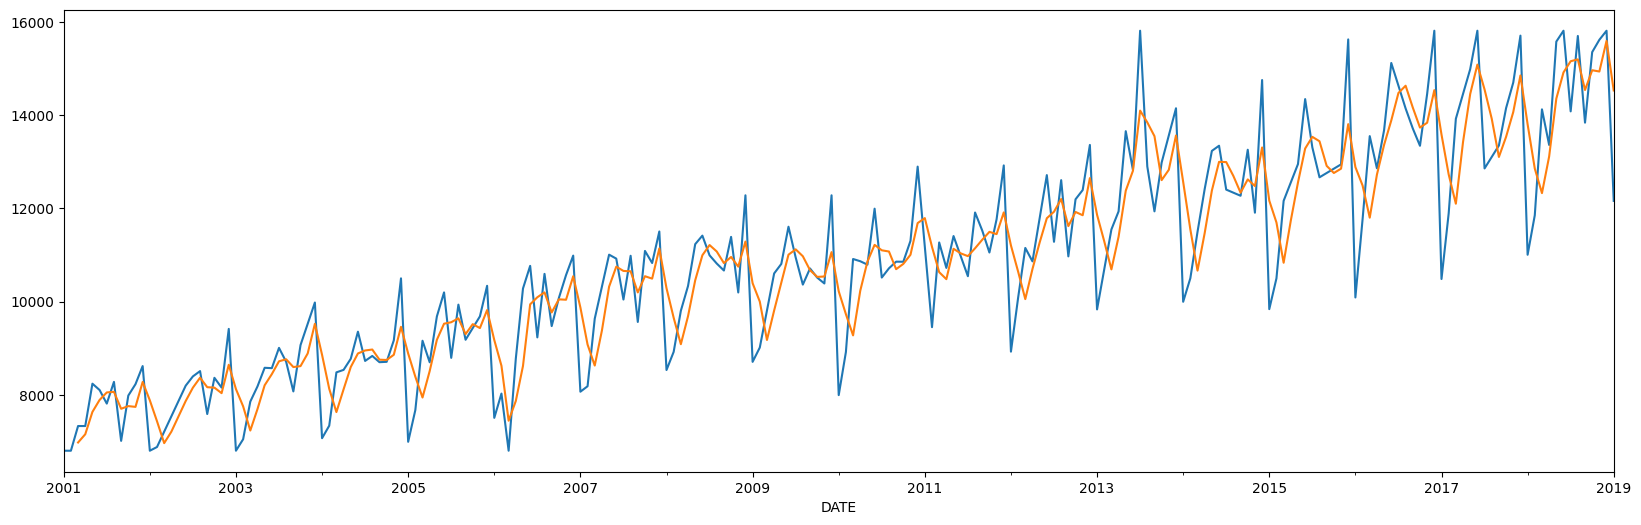

In [ ]:
# Plot original data
mobile_sales.Sales.plot(label='original')

# Plot data after implementing Moving Averages
mobile_sales.Sales.rolling(3, center=False).mean().plot(label='smoothed')

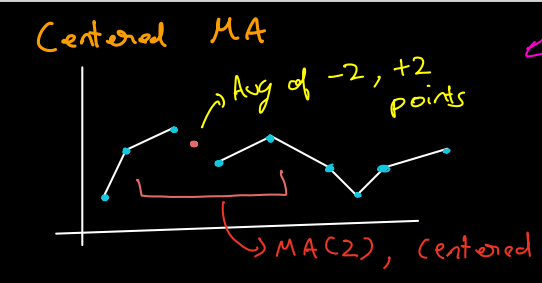

<Axes: xlabel='DATE'>

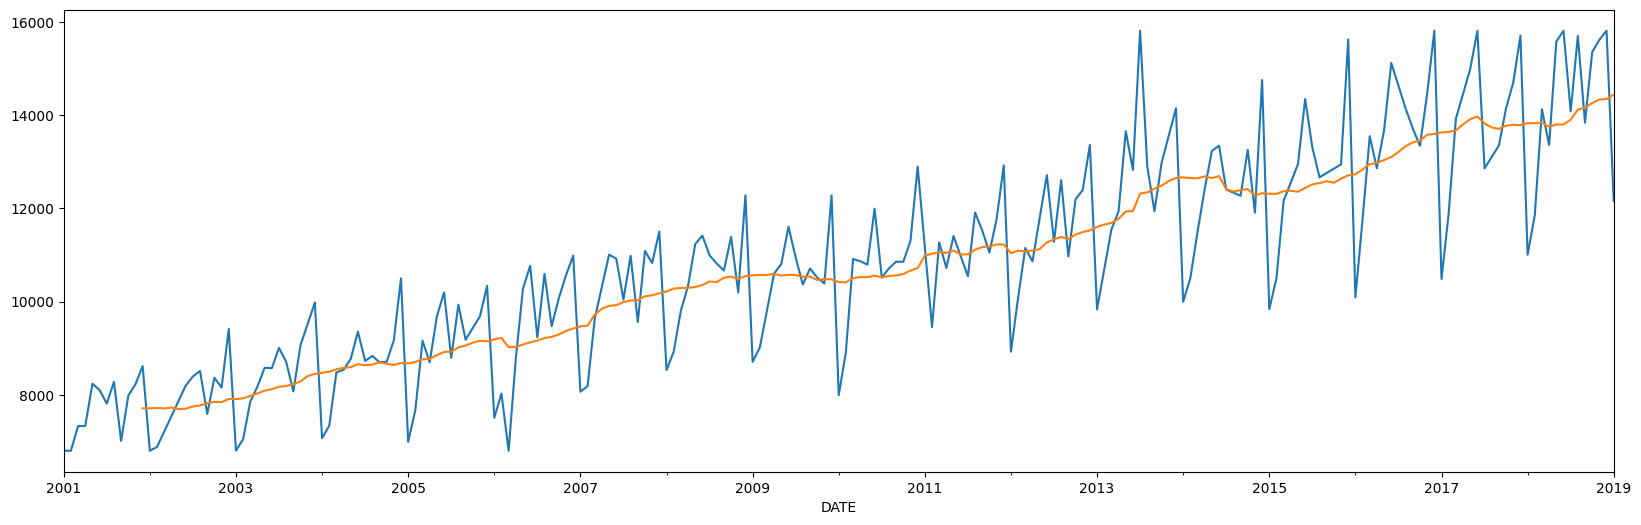

In [ ]:
# Plot original data
mobile_sales.Sales.plot(label='original')

# Plot data after implementing Moving Averages
mobile_sales.Sales.rolling(12, center=False).mean().plot(label='smoothed')

In [ ]:
import statsmodels.api as sm

model = sm.tsa.seasonal_decompose(mobile_sales.Sales, model='additive')

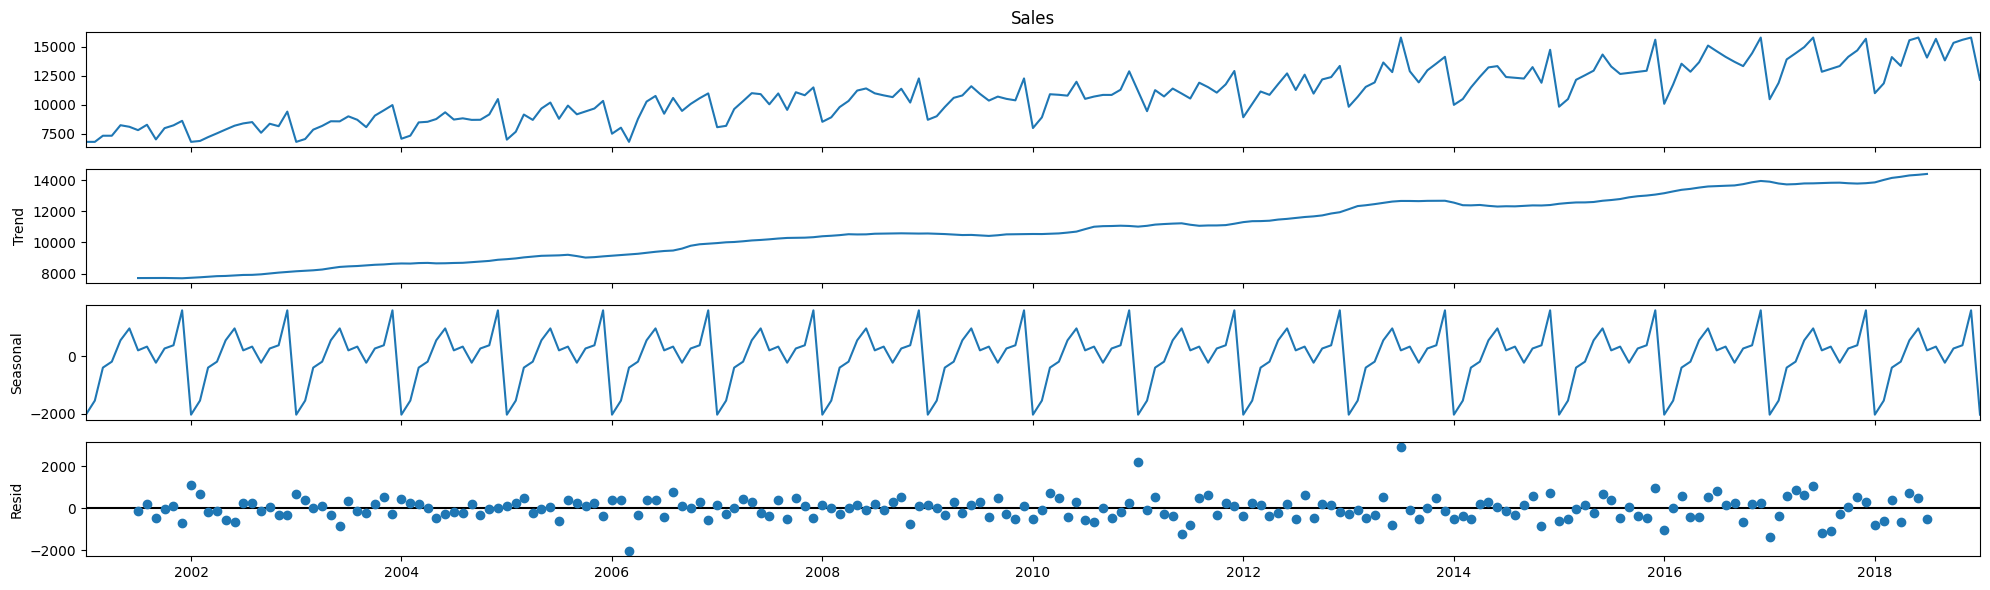

In [ ]:
model.plot();

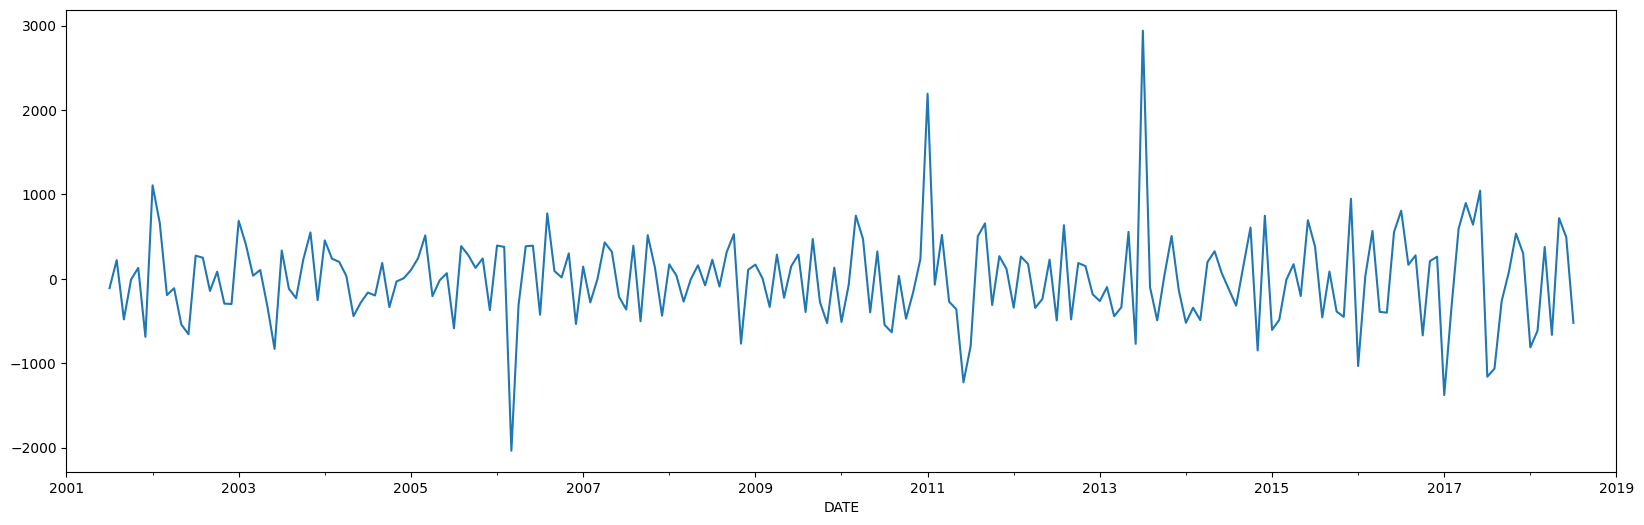

In [ ]:
model.resid.plot();

<Axes: >

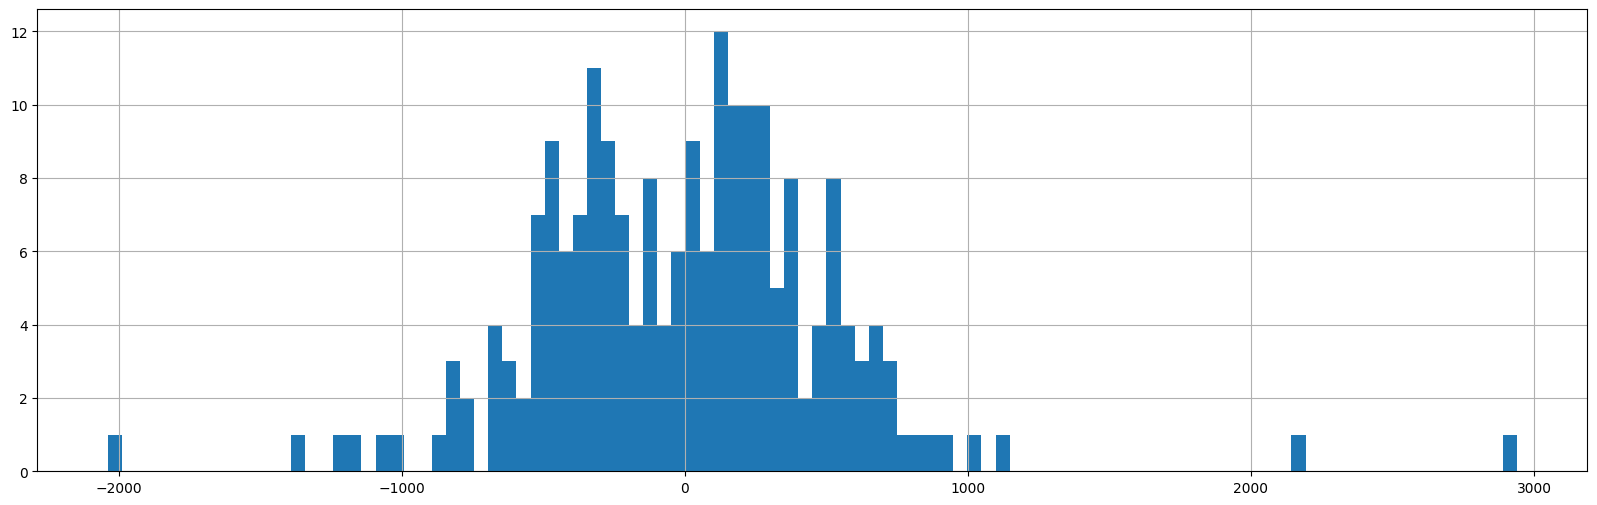

In [ ]:
model.resid.hist(bins = 100)

In [ ]:
model.resid.mean()

np.float64(-3.2316417029771514)

## Plan of action
1. Train test split
2. use simple forecasting methods
3. Evaluate those methods using MAPE

In [ ]:
train_max_date = mobile_sales.index[-12]

In [ ]:
train_x = mobile_sales.loc[mobile_sales.index < mobile_sales.index[-12]].copy()

In [ ]:
test_x = mobile_sales.loc[mobile_sales.index >= mobile_sales.index[-12]].copy()

In [ ]:
train_x

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00
...,...
2017-09-01,13349.00
2017-10-01,14150.00
2017-11-01,14698.00


In [ ]:
test_x

,Sales
DATE,
2018-02-01,11852.0
2018-03-01,14123.0
2018-04-01,13360.0
2018-05-01,15576.0
2018-06-01,15809.4
2018-07-01,14080.0
2018-08-01,15697.0
2018-09-01,13838.0
2018-10-01,15351.0


## Function to evaluate the model

In [ ]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

In [ ]:
# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

## Simple , Naive, Seasonal Naive, Drift Method

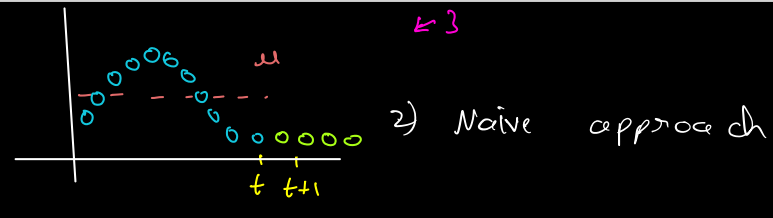

In [ ]:
train_x

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00
...,...
2017-09-01,13349.00
2017-10-01,14150.00
2017-11-01,14698.00


In [ ]:
test_x['pred'] = train_x['Sales'][-1]

/tmp/ipython-input-4166961390.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_x['pred'] = train_x['Sales'][-1]


In [ ]:
test_x

,Sales,pred
DATE,,
2018-02-01,11852.0,11005.0
2018-03-01,14123.0,11005.0
2018-04-01,13360.0,11005.0
2018-05-01,15576.0,11005.0
2018-06-01,15809.4,11005.0
2018-07-01,14080.0,11005.0
2018-08-01,15697.0,11005.0
2018-09-01,13838.0,11005.0
2018-10-01,15351.0,11005.0


<Axes: xlabel='DATE'>

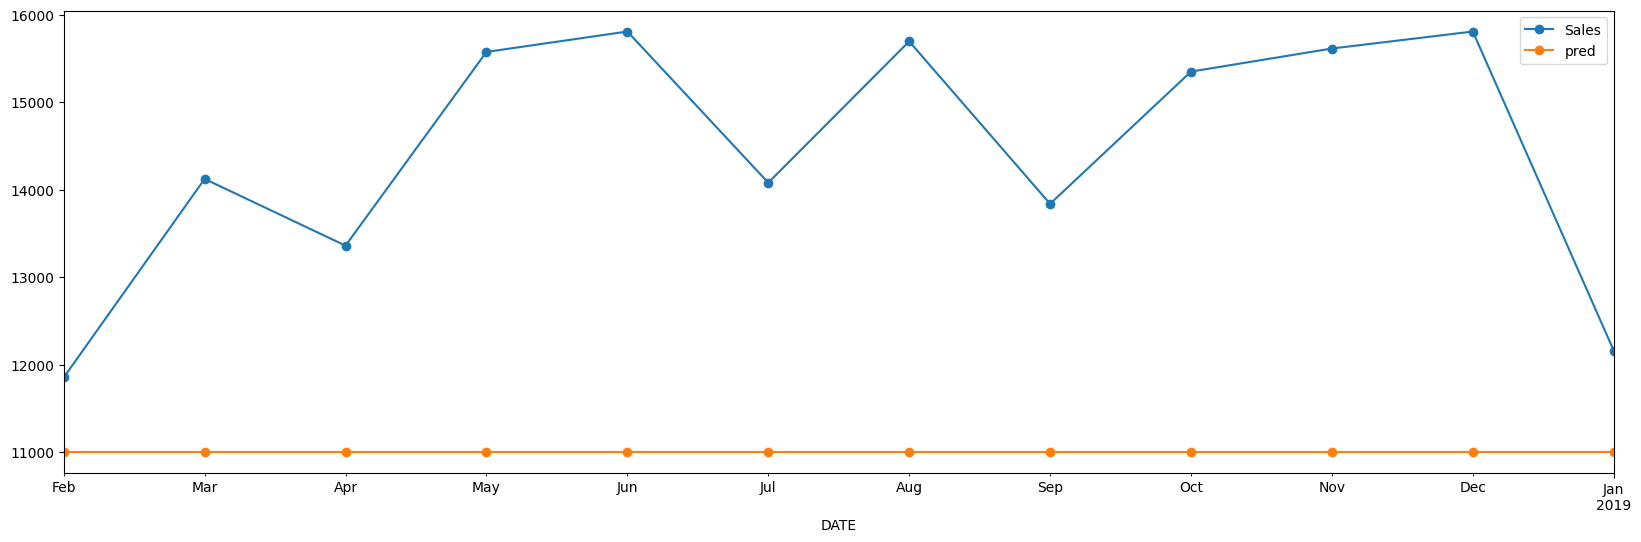

In [ ]:
test_x.plot(style='-o')

In [ ]:
performance(test_x['Sales'], test_x['pred'])

MAE : 3434.233
RMSE : 3697.005
MAPE: 0.23


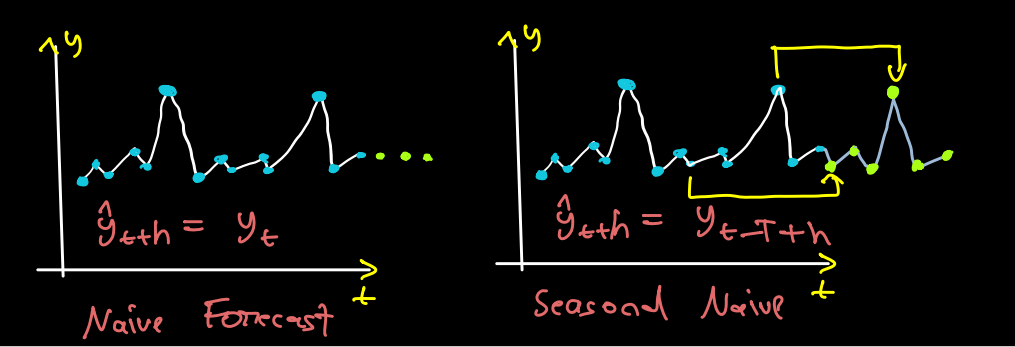

In [ ]:
test_x

,Sales,pred
DATE,,
2018-02-01,11852.0,11005.0
2018-03-01,14123.0,11005.0
2018-04-01,13360.0,11005.0
2018-05-01,15576.0,11005.0
2018-06-01,15809.4,11005.0
2018-07-01,14080.0,11005.0
2018-08-01,15697.0,11005.0
2018-09-01,13838.0,11005.0
2018-10-01,15351.0,11005.0


In [ ]:
for i in test_x.index:
  test_x.loc[i]['pred'] = train_x.loc[i - pd.DateOffset(years = 1)]['Sales']

/tmp/ipython-input-3108855094.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_x.loc[i]['pred'] = train_x.loc[i - pd.DateOffset(years = 1)]['Sales']


In [ ]:
test_x

,Sales,pred
DATE,,
2018-02-01,11852.0,11005.0
2018-03-01,14123.0,11005.0
2018-04-01,13360.0,11005.0
2018-05-01,15576.0,11005.0
2018-06-01,15809.4,11005.0
2018-07-01,14080.0,11005.0
2018-08-01,15697.0,11005.0
2018-09-01,13838.0,11005.0
2018-10-01,15351.0,11005.0


In [ ]:
for i in test_x.index:
  test_x.loc[i, 'pred'] = train_x.loc[i - pd.DateOffset(years=1), 'Sales']

In [ ]:
test_x

,Sales,pred
DATE,,
2018-02-01,11852.0,11891.0
2018-03-01,14123.0,13921.0
2018-04-01,13360.0,14453.5
2018-05-01,15576.0,14986.0
2018-06-01,15809.4,15809.4
2018-07-01,14080.0,12856.0
2018-08-01,15697.0,13102.5
2018-09-01,13838.0,13349.0
2018-10-01,15351.0,14150.0


MAE : 800.867
RMSE : 1067.837
MAPE: 0.055


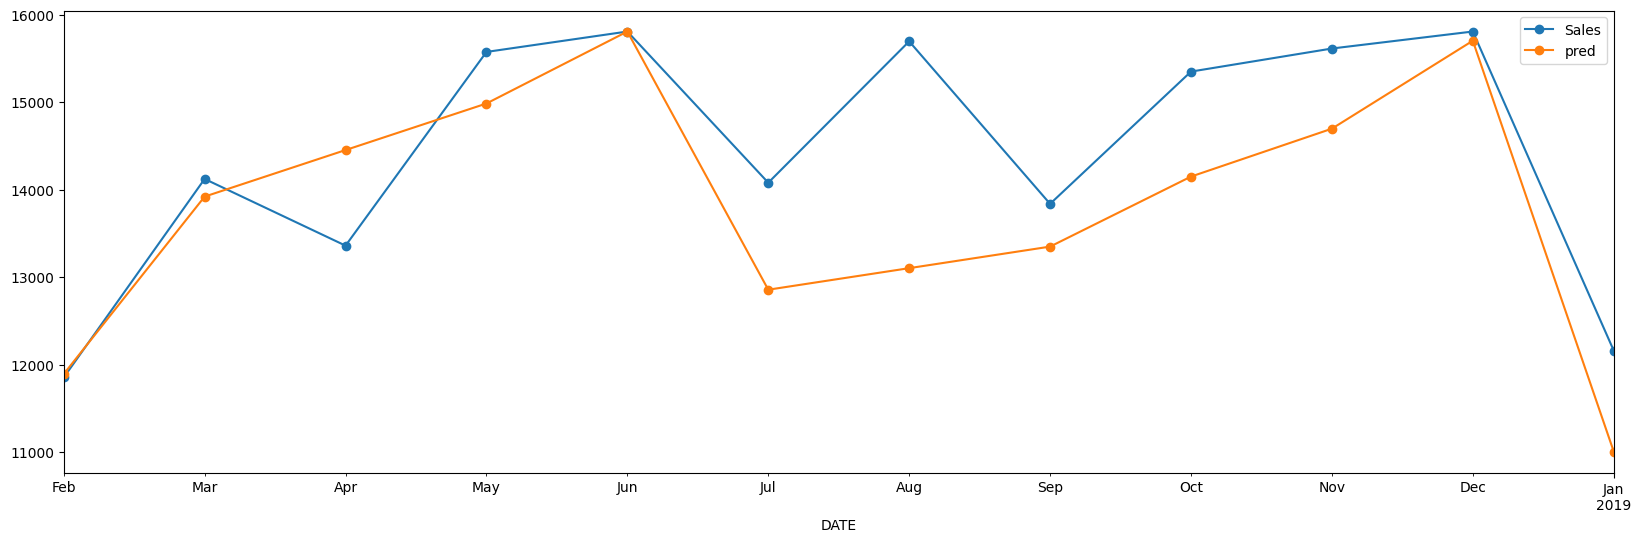

In [ ]:
test_x.plot(style='-o')

performance(test_x['Sales'], test_x['pred'])

## Drift method

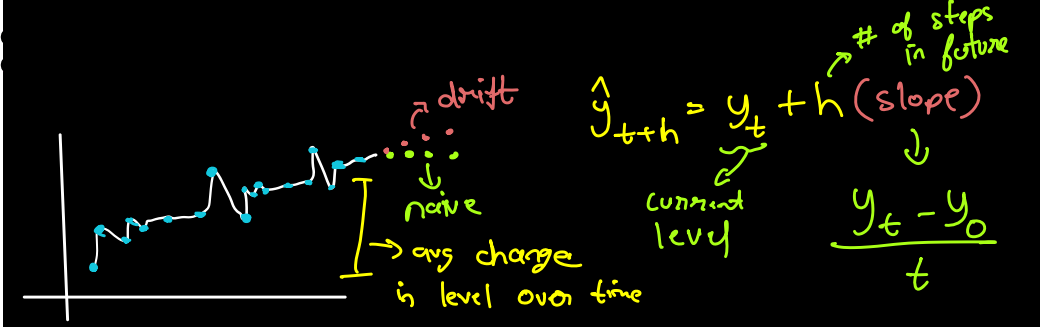

In [ ]:
y_t = train_x['Sales'][-2]

m = (y_t - train_x['Sales'][0]) / len(train_x)

h = np.linspace(0,len(test_x)-1, len(test_x))


/tmp/ipython-input-3668366550.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_t = train_x['Sales'][-2]
/tmp/ipython-input-3668366550.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m = (y_t - train_x['Sales'][0]) / len(train_x)


In [ ]:
test_x

,Sales,pred
DATE,,
2018-02-01,11852.0,11891.0
2018-03-01,14123.0,13921.0
2018-04-01,13360.0,14453.5
2018-05-01,15576.0,14986.0
2018-06-01,15809.4,15809.4
2018-07-01,14080.0,12856.0
2018-08-01,15697.0,13102.5
2018-09-01,13838.0,13349.0
2018-10-01,15351.0,14150.0


In [ ]:
test_x['pred'] = y_t + m * h

In [ ]:
test_x

,Sales,pred
DATE,,
2018-02-01,11852.0,15704.000000
2018-03-01,14123.0,15747.422244
2018-04-01,13360.0,15790.844488
2018-05-01,15576.0,15834.266732
2018-06-01,15809.4,15877.688976
2018-07-01,14080.0,15921.111220
2018-08-01,15697.0,15964.533463
2018-09-01,13838.0,16007.955707
2018-10-01,15351.0,16051.377951


<Axes: xlabel='DATE'>

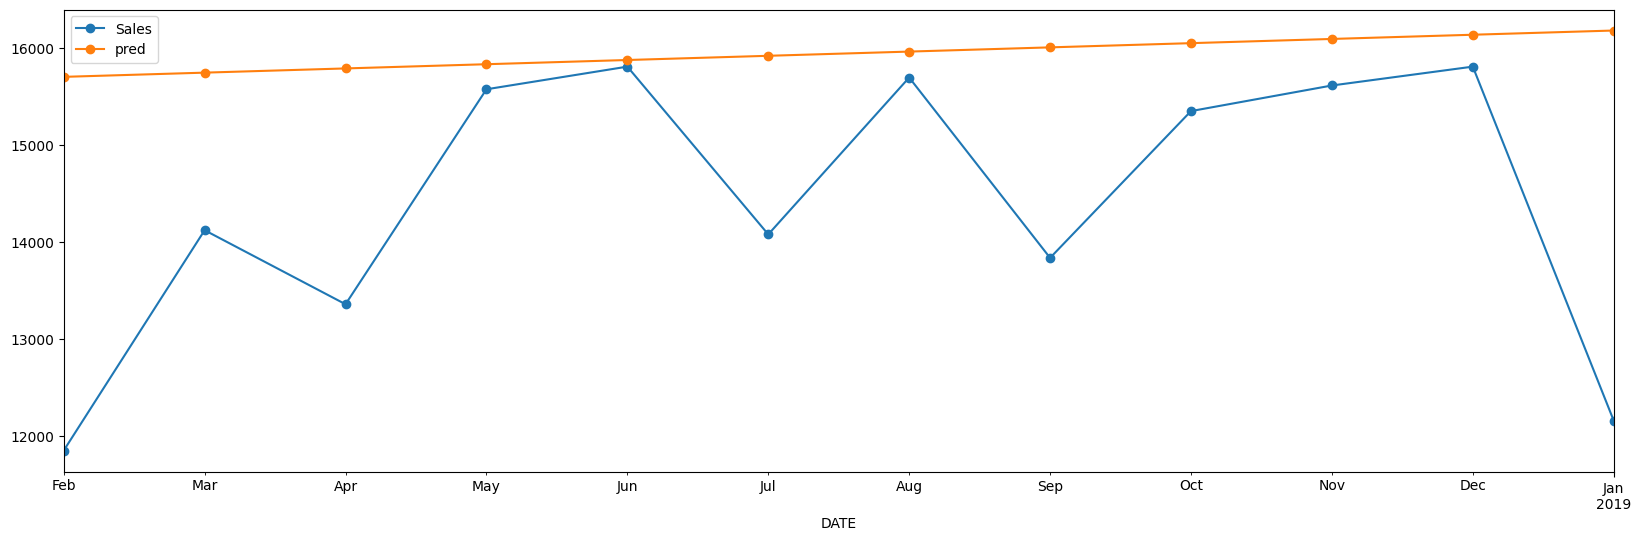

In [ ]:
test_x.plot(style='-o')

In [ ]:
performance(test_x['Sales'], test_x['pred'])


MAE : 1503.589
RMSE : 2013.071
MAPE: 0.115


In [ ]:
import numpy as np

df = mobile_sales.copy()

In [ ]:
pd.DataFrame(index = pd.date_range(start=df.index[-1], periods=12,freq='MS'))


""
2019-01-01
2019-02-01
2019-03-01
2019-04-01
2019-05-01
2019-06-01
2019-07-01
2019-08-01
2019-09-01
2019-10-01


In [ ]:
future_index = pd.date_range(
    start=df.index[-1],
    periods=13,
    freq='MS'
)[1:]

df = pd.concat([df, pd.DataFrame(index=future_index)])


In [ ]:
df.tail(20)

,Sales
2018-06-01,15809.4
2018-07-01,14080.0
2018-08-01,15697.0
2018-09-01,13838.0
2018-10-01,15351.0
2018-11-01,15615.0
2018-12-01,15809.4
2019-01-01,12160.0
2019-02-01,NaN
2019-03-01,NaN


In [ ]:
pred = df.Sales.dropna().values

In [ ]:
for i in range(12):
  pred = np.append(pred, pred[-3:].mean())

In [ ]:
pred[-20:]


array([15809.4       , 14080.        , 15697.        , 13838.        ,
       15351.        , 15615.        , 15809.4       , 12160.        ,
       14528.13333333, 14165.84444444, 13617.99259259, 14103.99012346,
       13962.6090535 , 13894.86392318, 13987.15436671, 13948.20911446,
       13943.40913479, 13959.59087199, 13950.40304041, 13951.13434906])

In [ ]:
pred = pred.round(1)
pred[-20:]

array([15809.4, 14080. , 15697. , 13838. , 15351. , 15615. , 15809.4,
       12160. , 14528.1, 14165.8, 13618. , 14104. , 13962.6, 13894.9,
       13987.2, 13948.2, 13943.4, 13959.6, 13950.4, 13951.1])

In [ ]:
df['pred'] = pred

<Axes: >

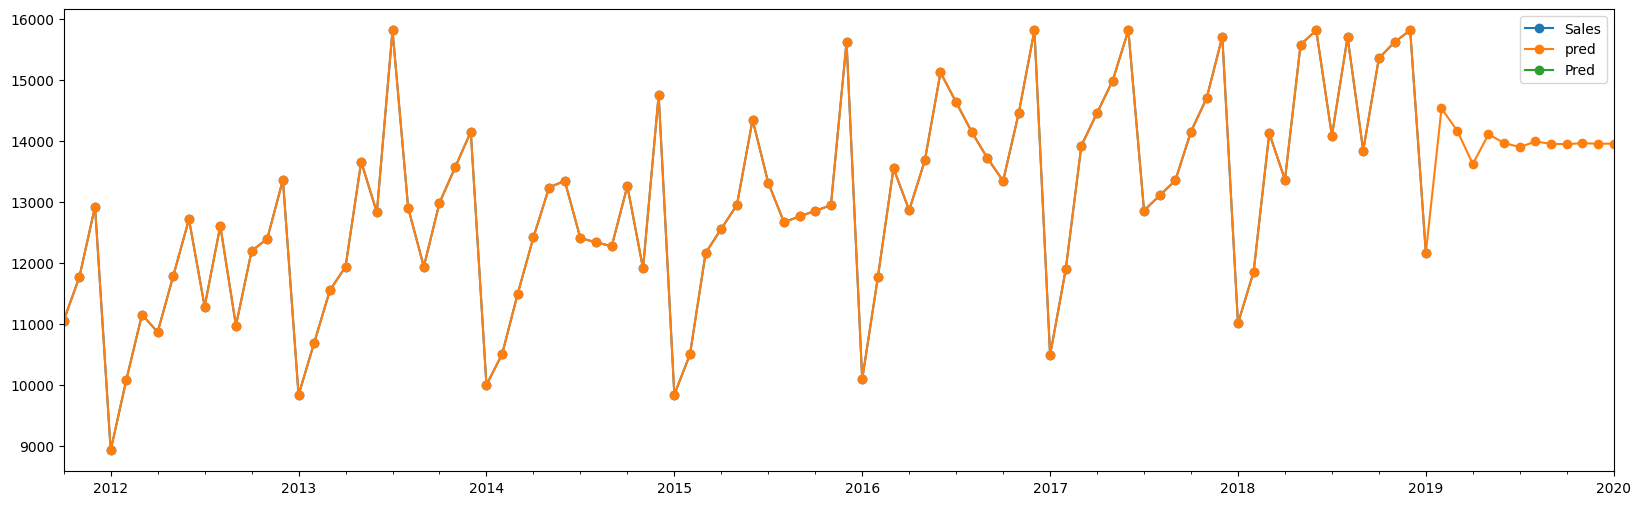

In [ ]:
df.loc[~df['Sales'].isna(), 'Pred'] = np.nan
df.tail(100).plot(style='-o')

## HW to find the performance of MA of diff window sizes

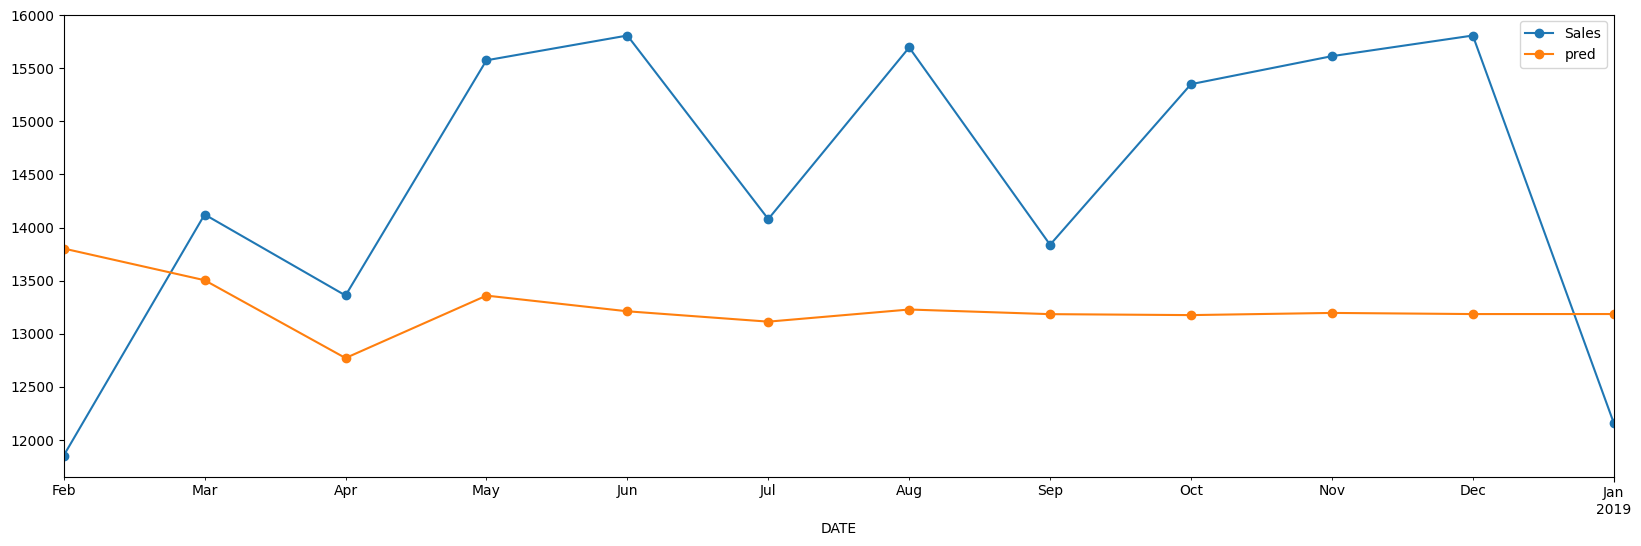

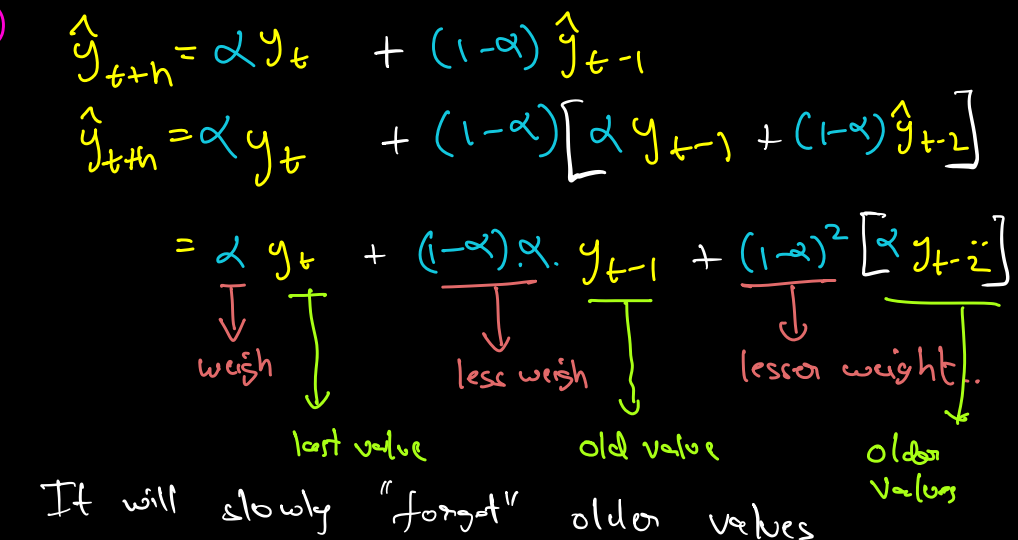

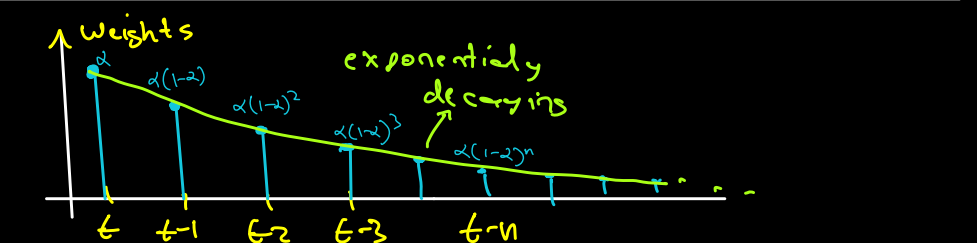

In [ ]:
model = pd.Series(sm.tsa.SimpleExpSmoothing(mobile_sales.Sales).fit(smoothing_level=1/(2*12)).fittedvalues)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


<Axes: xlabel='DATE'>

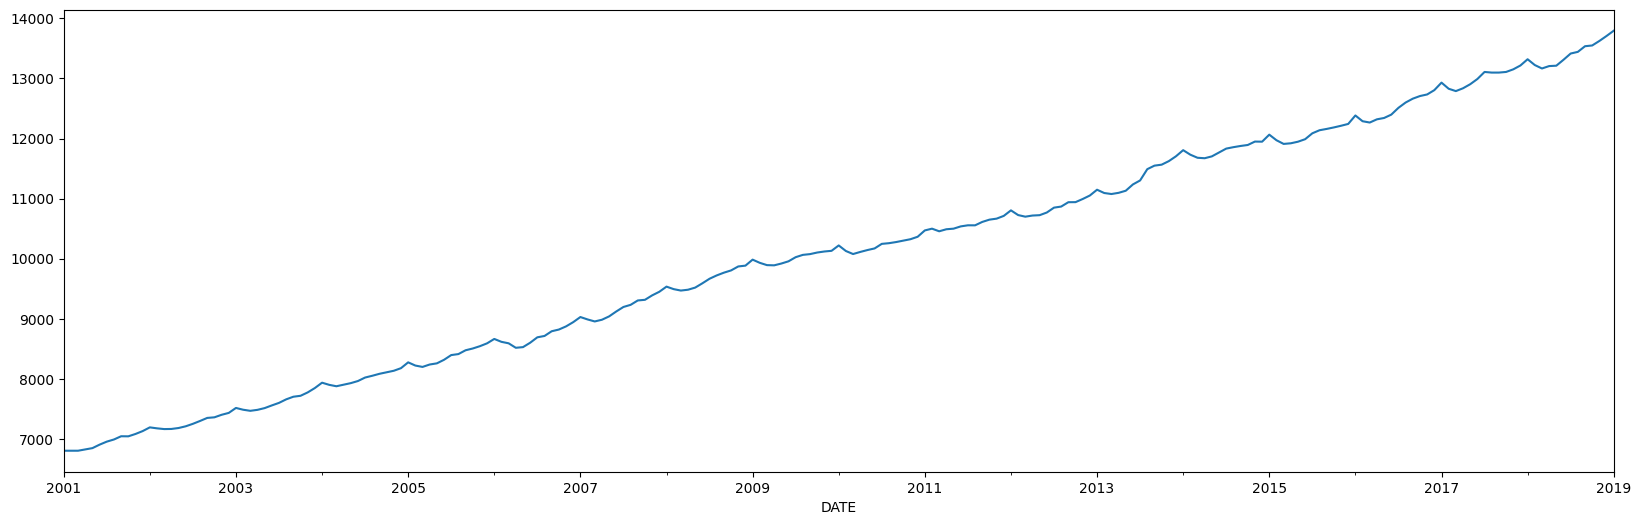

In [ ]:
model.plot(label = 'ses')

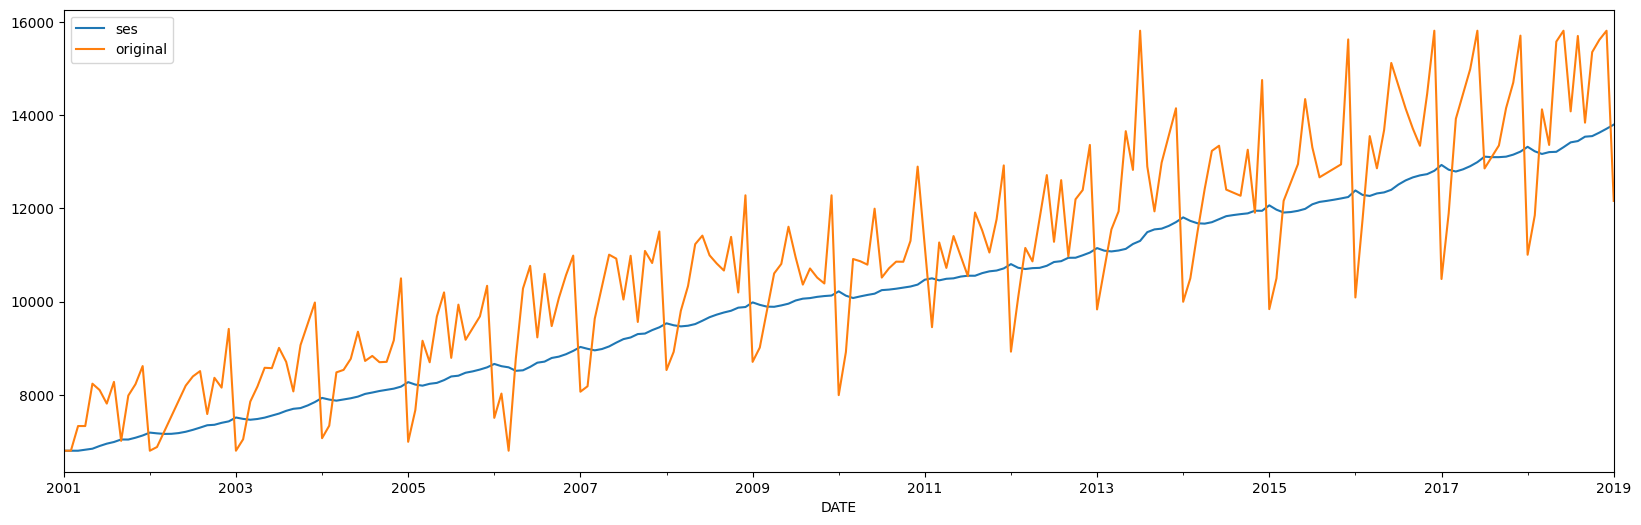

In [ ]:
model.plot(label='ses')
mobile_sales.Sales.plot(label='original')
plt.legend()

## Prediction

In [ ]:
model = sm.tsa.SimpleExpSmoothing(mobile_sales.Sales).fit(smoothing_level=1/(2*12))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


In [ ]:
pred = model.forecast(steps = 12)

In [ ]:
pred

,0
2019-02-01,13726.902325
2019-03-01,13726.902325
2019-04-01,13726.902325
2019-05-01,13726.902325
2019-06-01,13726.902325
2019-07-01,13726.902325
2019-08-01,13726.902325
2019-09-01,13726.902325
2019-10-01,13726.902325
2019-11-01,13726.902325


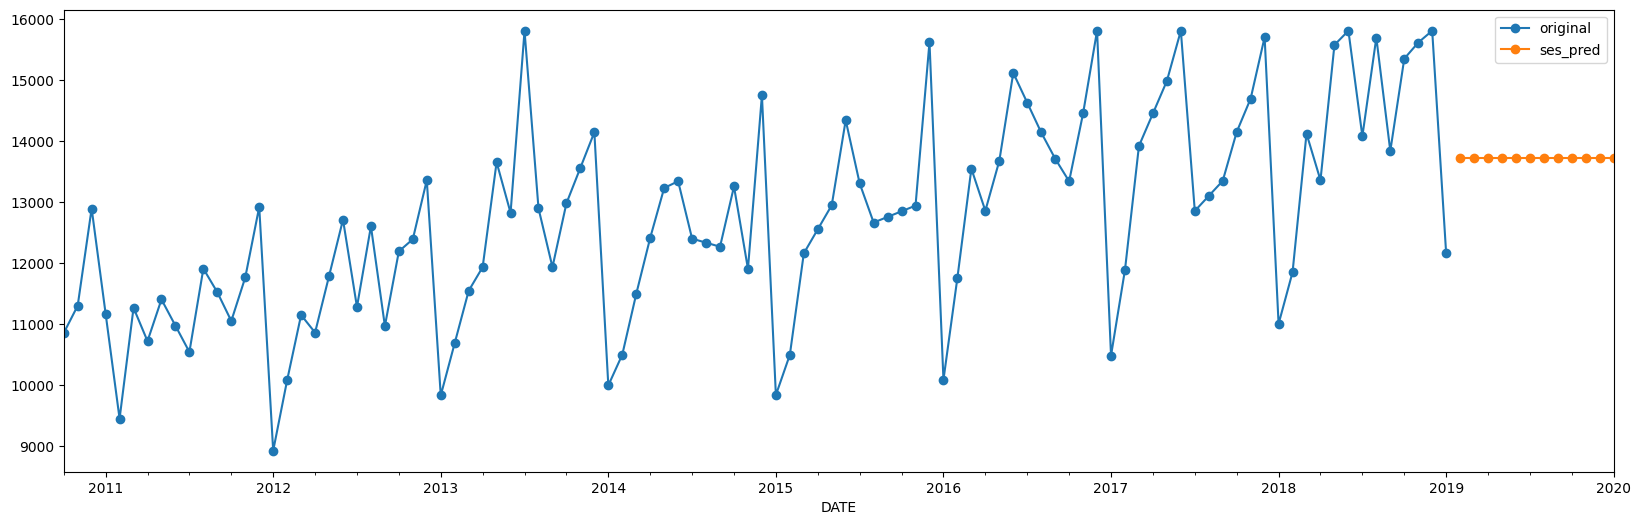

In [ ]:
mobile_sales.Sales.tail(100).plot(label='original', style='-o')

pred.plot(label='ses_pred', style='-o')
plt.legend()

In [ ]:
model = sm.tsa.SimpleExpSmoothing(train_x.Sales).fit(smoothing_level=1/(2*12))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


In [ ]:
test_x['pred'] = model.forecast(steps = 12)


MAE : 1621.49
RMSE : 1830.741
MAPE: 0.109


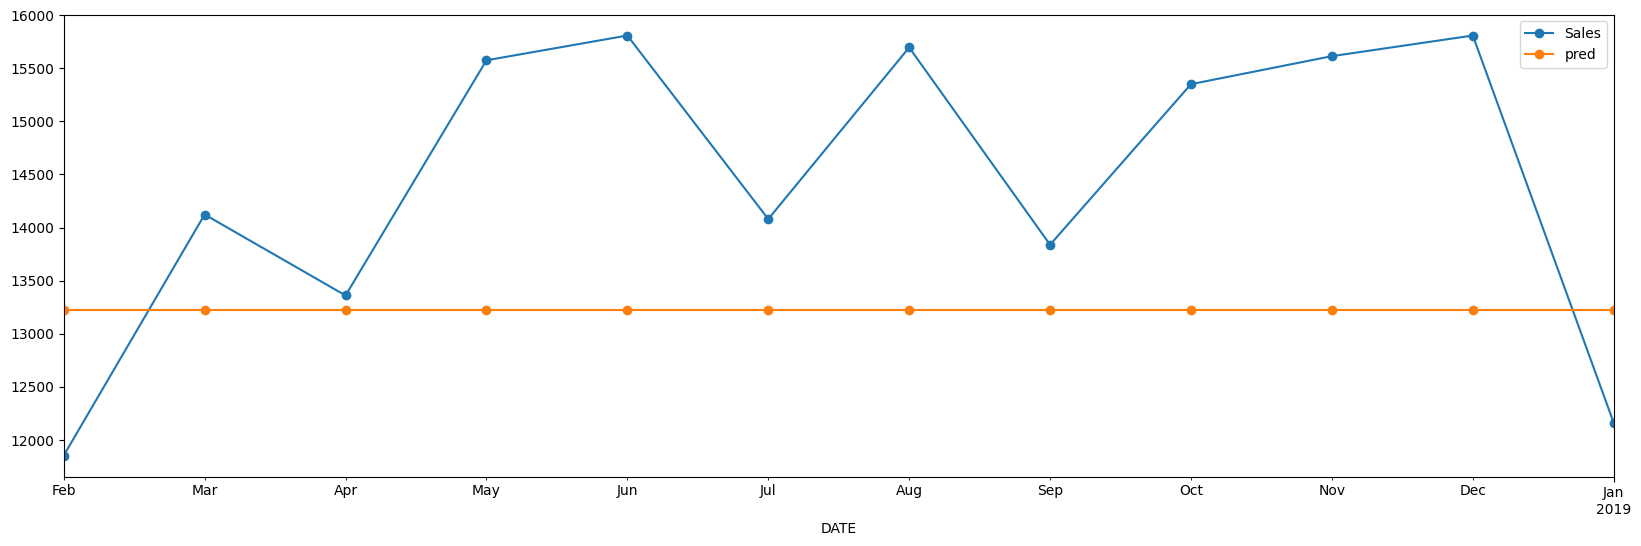

In [ ]:
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

## SES - Assumes No Trend or Seasonality

In [ ]:
model = sm.tsa.SimpleExpSmoothing(mobile_sales.Sales).fit(smoothing_level=1/(2*12))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


<Axes: xlabel='DATE'>

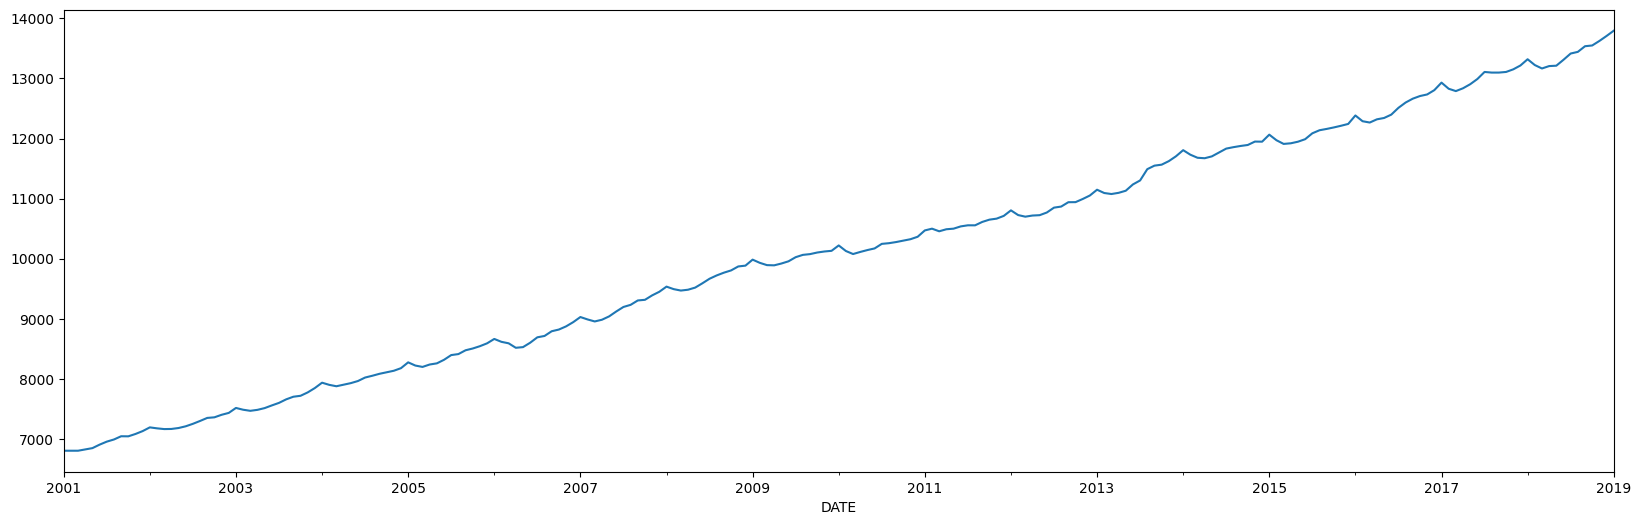

In [ ]:
model.fittedvalues.plot(label='fitted')

## Double exponential; Smoothing (Trend also )

In [ ]:
model = sm.tsa.ExponentialSmoothing(mobile_sales.Sales, trend='add').fit(smoothing_level=0.4)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


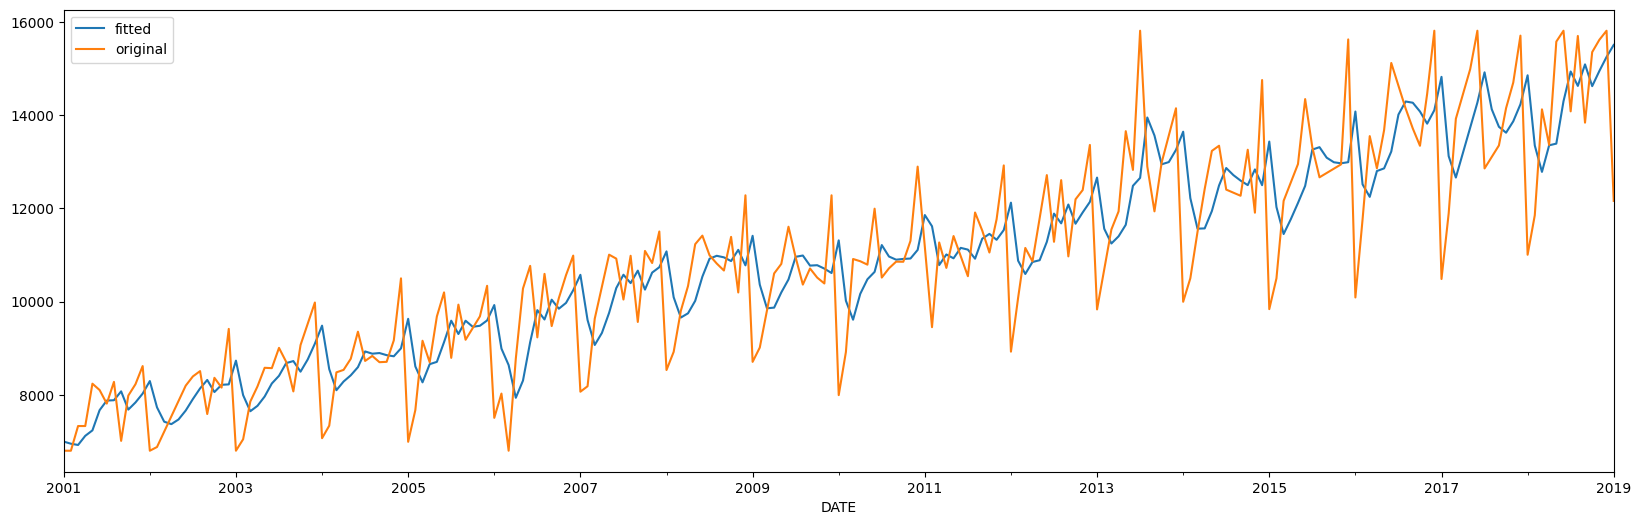

In [ ]:
model.fittedvalues.plot(label='fitted')
mobile_sales.Sales.plot(label='original')
plt.legend()

In [ ]:
pred = model.forecast(steps = 12)


<Axes: xlabel='DATE'>

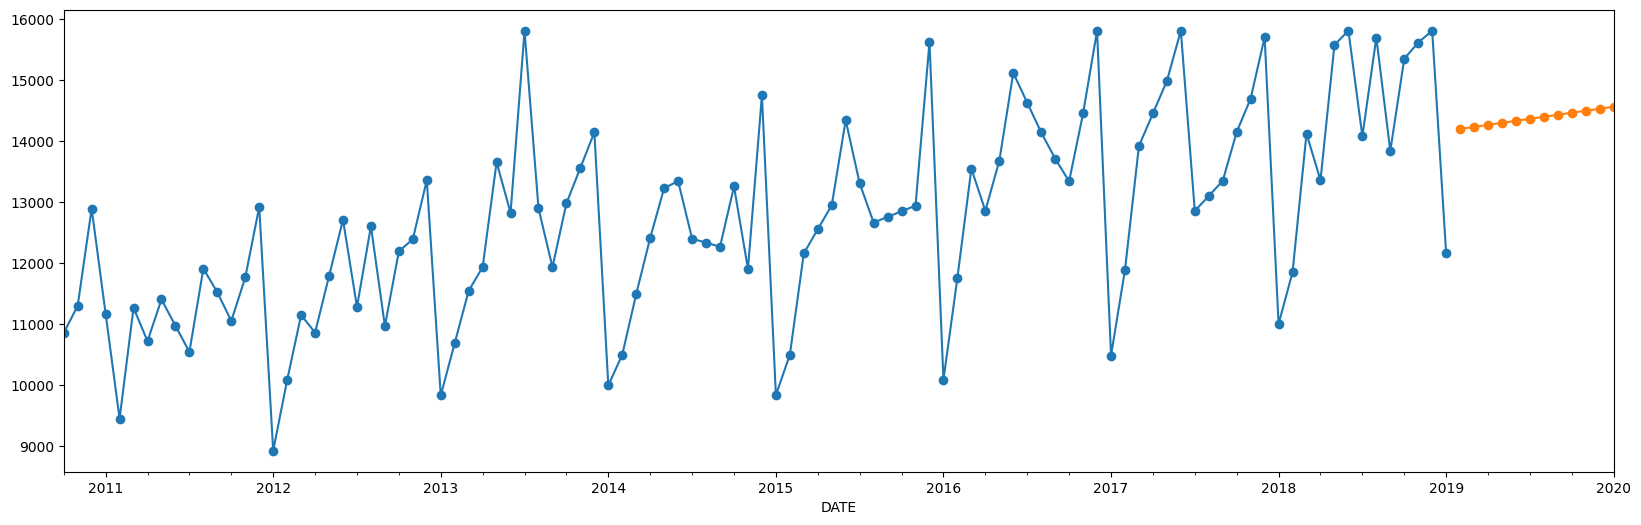

In [ ]:
mobile_sales.Sales.tail(100).plot(style='-o', label='actual')

pred.plot(style='-o', label='predicted')



In [ ]:
test_x

,Sales,pred
DATE,,
2018-02-01,11852.0,13223.615505
2018-03-01,14123.0,13223.615505
2018-04-01,13360.0,13223.615505
2018-05-01,15576.0,13223.615505
2018-06-01,15809.4,13223.615505
2018-07-01,14080.0,13223.615505
2018-08-01,15697.0,13223.615505
2018-09-01,13838.0,13223.615505
2018-10-01,15351.0,13223.615505


In [ ]:
model = sm.tsa.ExponentialSmoothing(train_x.Sales, trend='add').fit(smoothing_level=1/(2*12))
test_x['pred'] = model.forecast(steps = 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE : 1181.471
RMSE : 1370.344
MAPE: 0.083


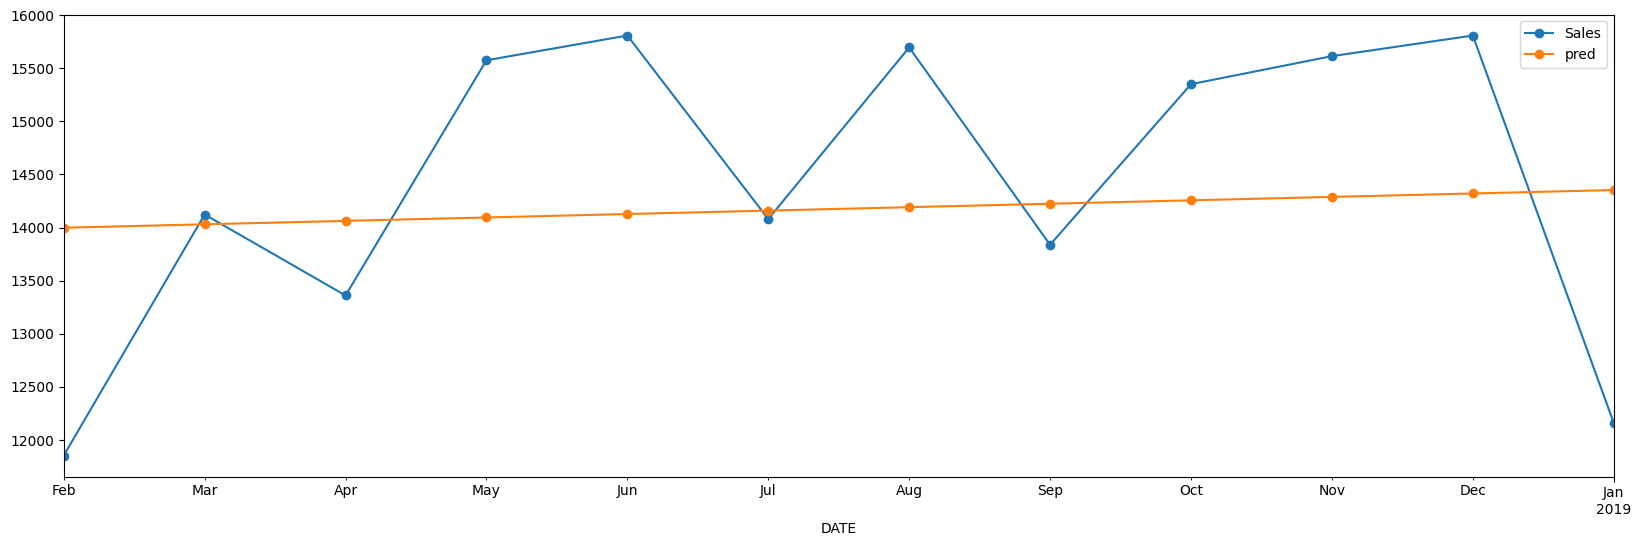

In [ ]:
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

In [ ]:
model = sm.tsa.ExponentialSmoothing(train_x.Sales, trend='add', seasonal = 'add').fit(smoothing_level=0.4)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


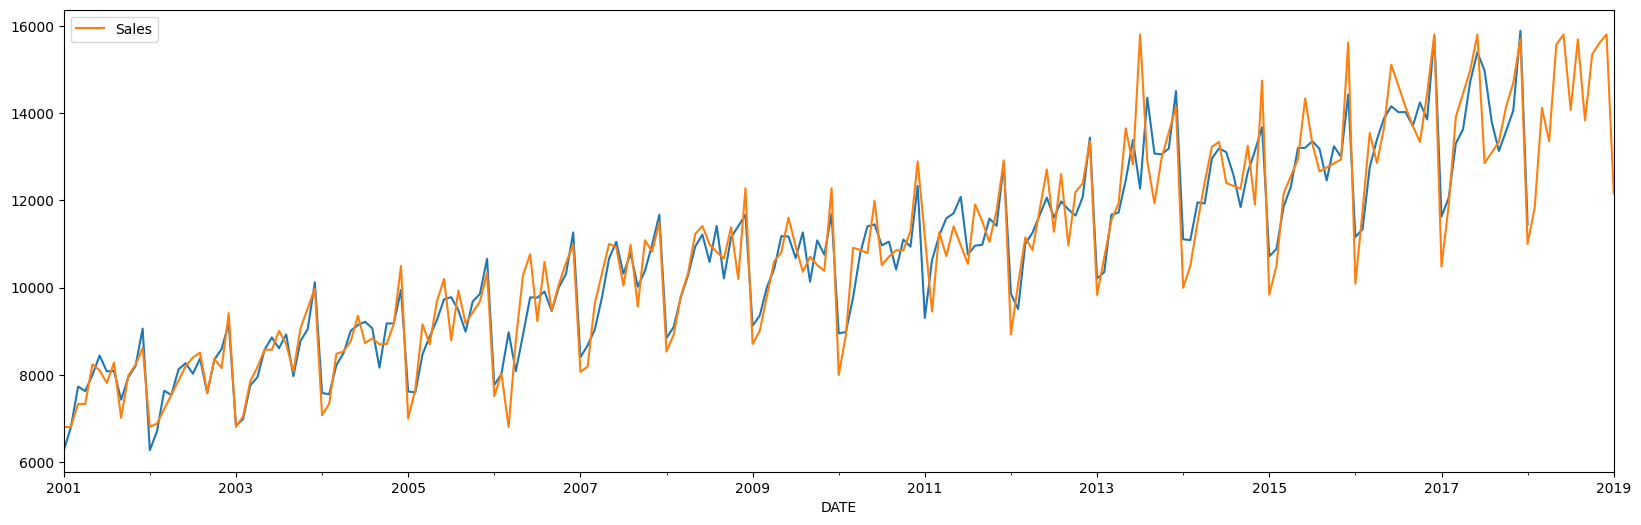

In [ ]:
model.fittedvalues.plot()
mobile_sales.Sales.plot()
plt.legend()

<Axes: xlabel='DATE'>

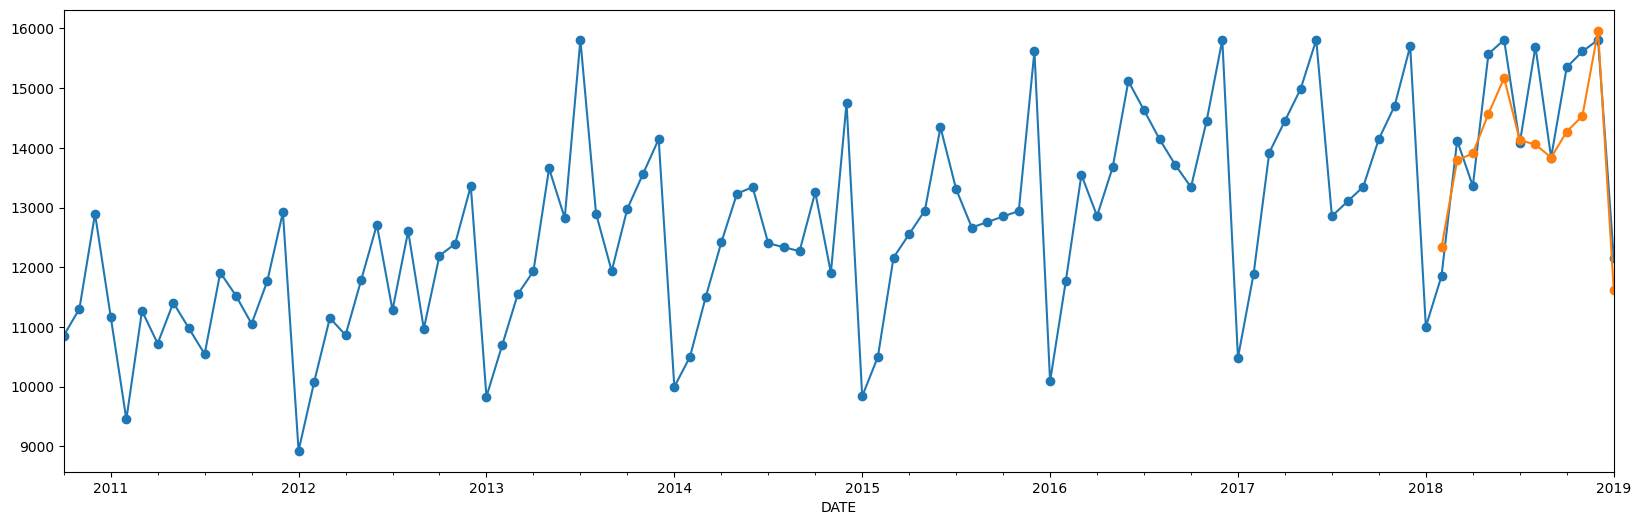

In [ ]:
pred = model.forecast(steps = 12)

mobile_sales.Sales.tail(100).plot(style='-o')
pred.plot(style='-o')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE : 590.018
RMSE : 687.309
MAPE: 0.04


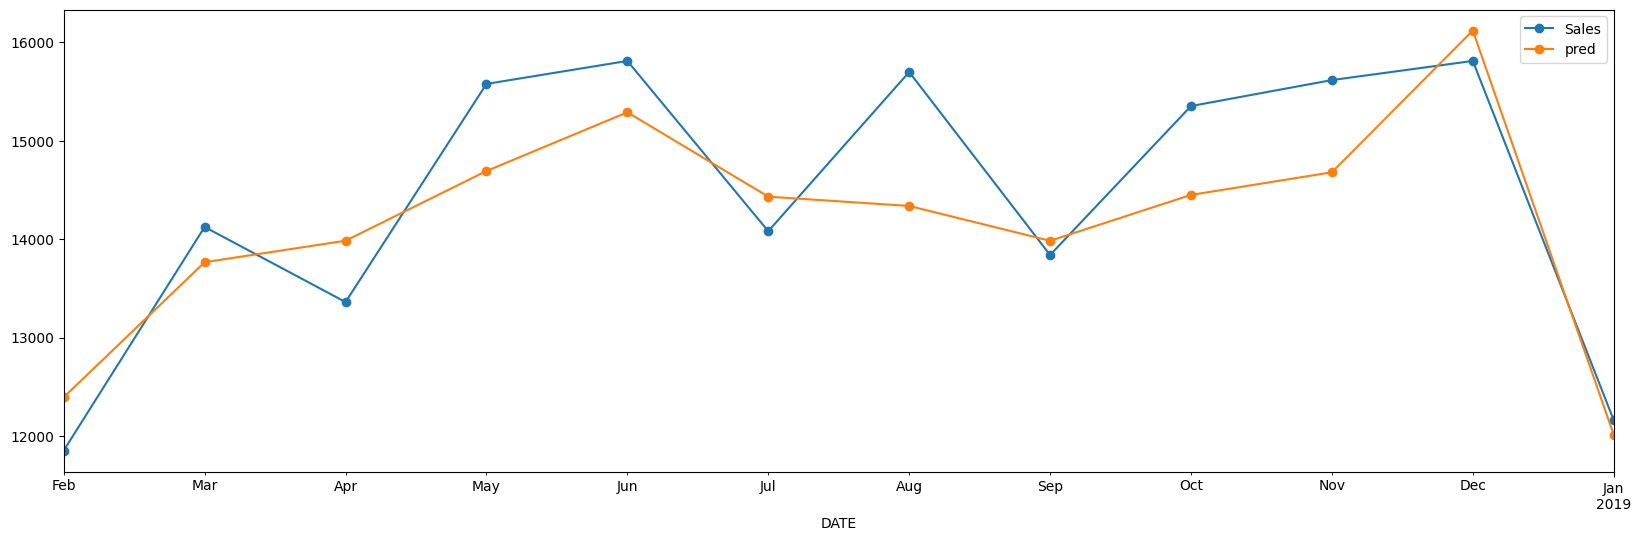

In [ ]:
model = sm.tsa.ExponentialSmoothing(train_x.Sales, trend='add', seasonal='add').fit(smoothing_level=1/(2*12))
test_x['pred'] = model.forecast(steps=12)
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

## Check if TS is stationary or not

In [ ]:
sm.tsa.stattools.adfuller(mobile_sales.Sales)[1]

np.float64(0.9789233920172065)

In [ ]:
def adf_test(dataset):
   pvalue = sm.tsa.stattools.adfuller(dataset)[1]
   if pvalue <= 0.05:
      print('Sequence is stationary')
   else:
      print('Sequence is not stationary')

adf_test(mobile_sales.Sales)

Sequence is not stationary


<Axes: xlabel='DATE'>

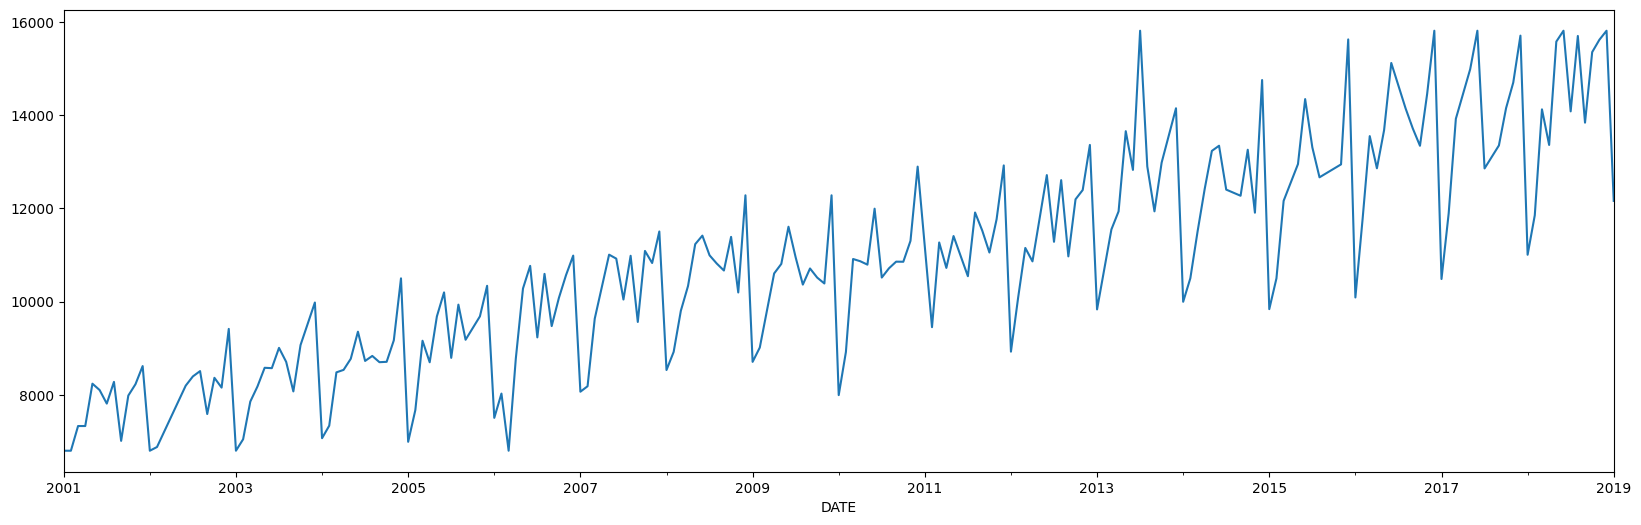

In [ ]:
mobile_sales.Sales.plot()

In [ ]:
# original series
mobile_sales.Sales


,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00
...,...
2018-09-01,13838.00
2018-10-01,15351.00
2018-11-01,15615.00


In [ ]:
# shifted series (lag by 1)
mobile_sales.Sales - mobile_sales.Sales.shift(1)

,Sales
DATE,
2001-01-01,NaN
2001-02-01,0.00
2001-03-01,529.56
2001-04-01,0.00
2001-05-01,908.00
...,...
2018-09-01,-1859.00
2018-10-01,1513.00
2018-11-01,264.00


<Axes: xlabel='DATE'>

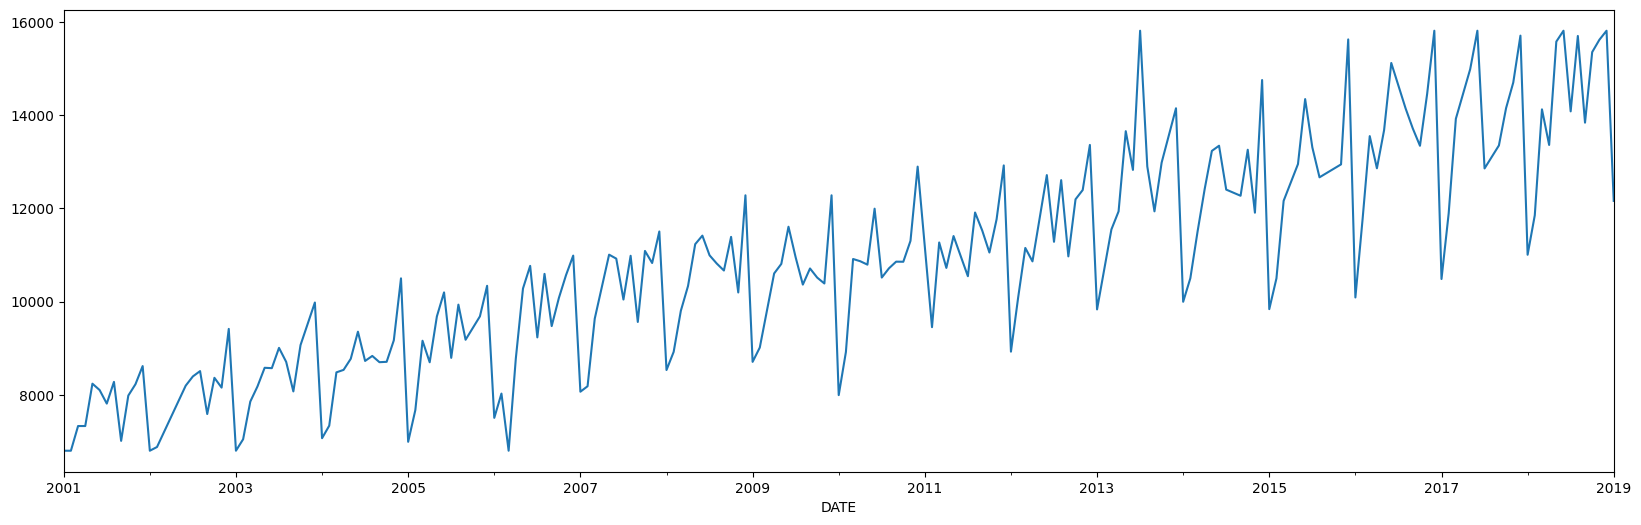

In [ ]:
mobile_sales.Sales.plot()

<Axes: xlabel='DATE'>

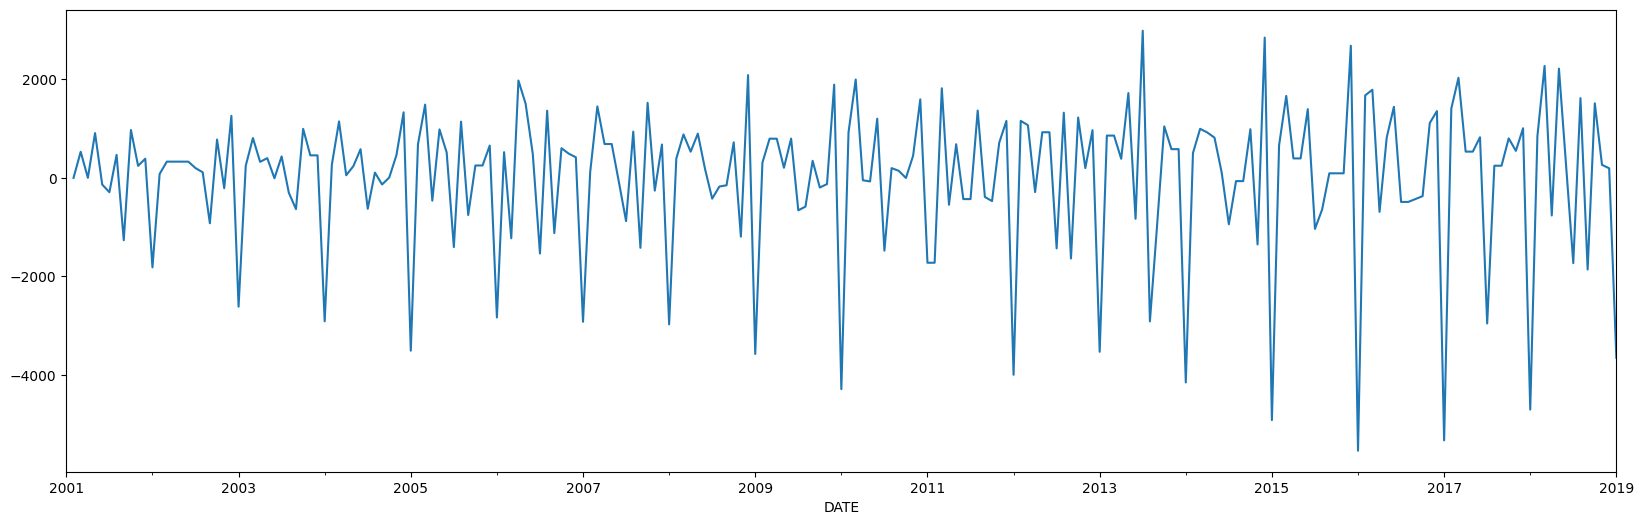

In [ ]:
detrend = mobile_sales.Sales.diff()
detrend.plot()


<Axes: xlabel='DATE'>

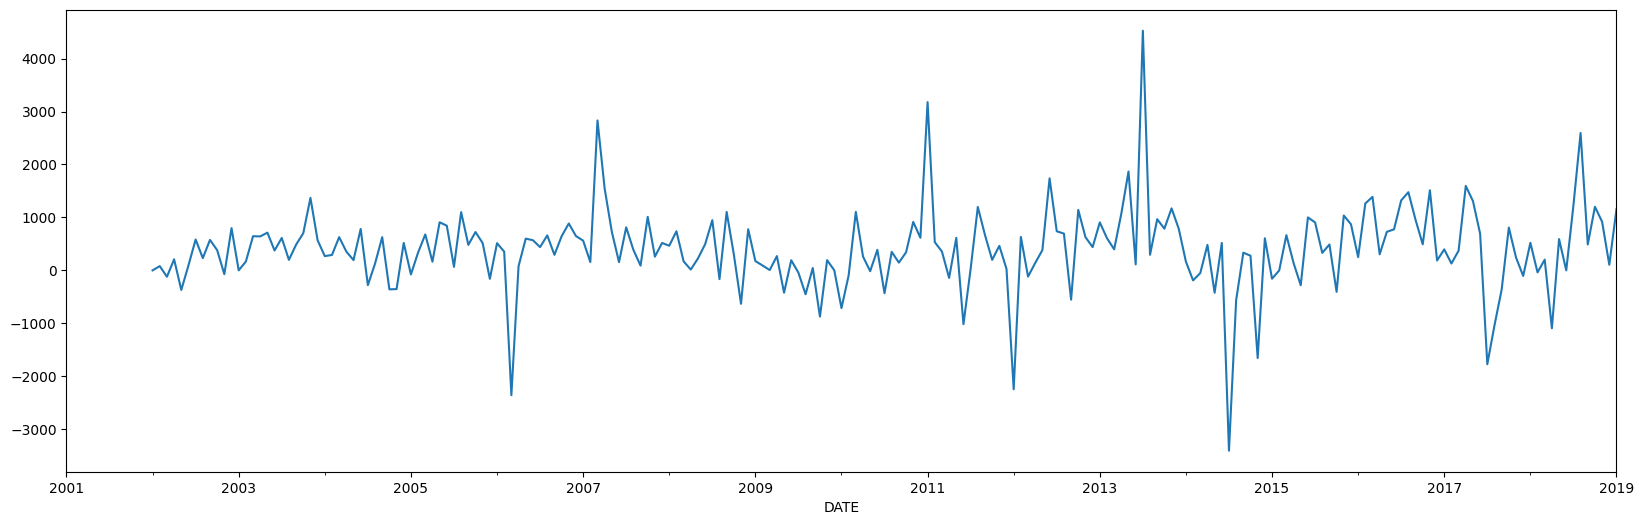

In [ ]:
deseas = mobile_sales.Sales.diff(12)
deseas.plot()


<Axes: xlabel='DATE'>

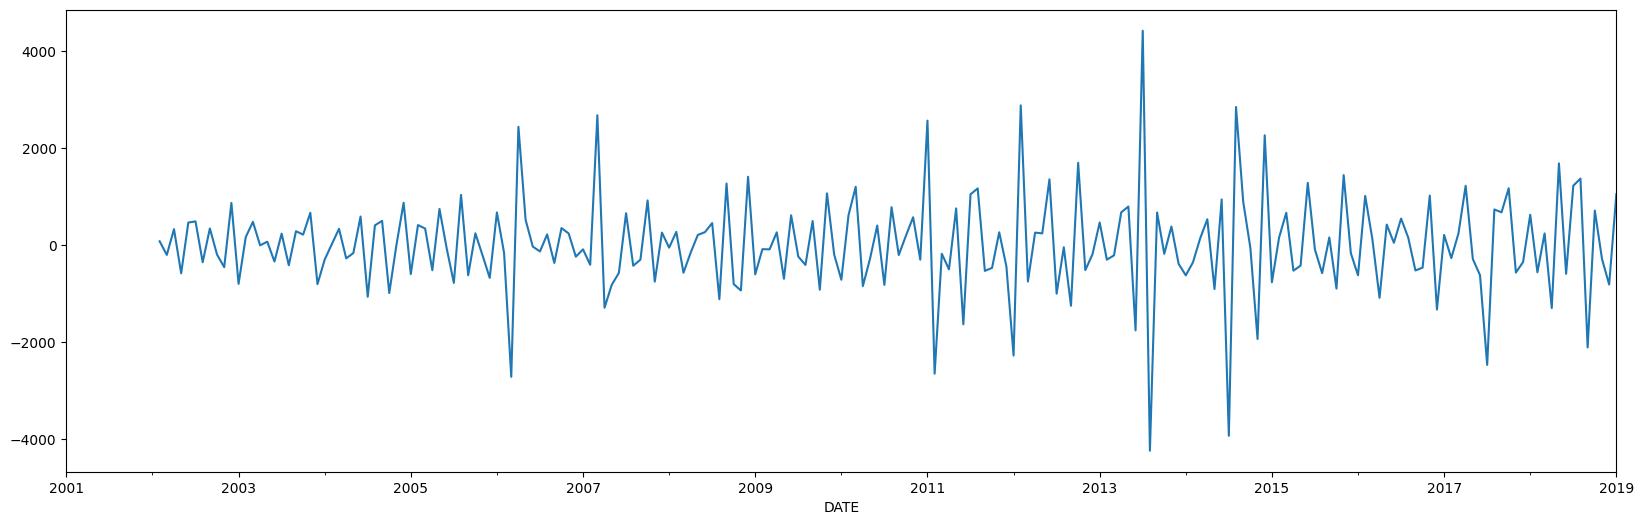

In [ ]:
stationary = mobile_sales.Sales.diff(1).diff(12)
stationary.plot()

In [ ]:
adf_test(detrend.dropna())


Sequence is stationary


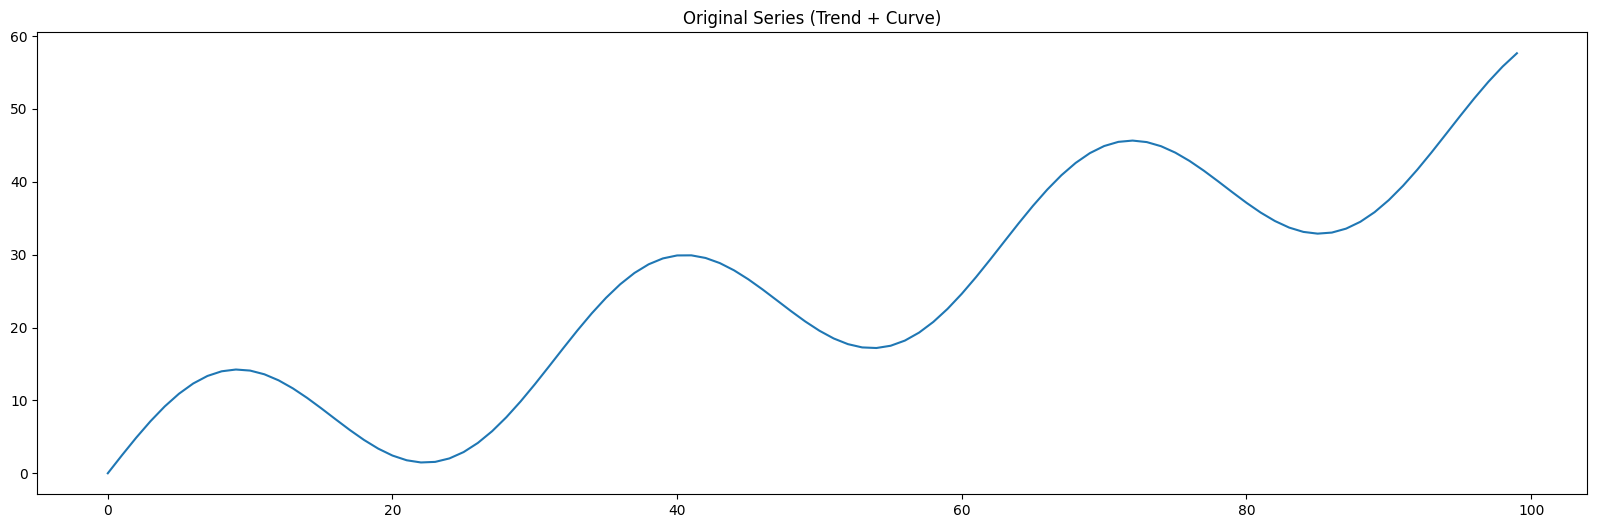

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# create a simple curve: trend + wave
x = np.arange(100)
y = 0.5 * x + 10 * np.sin(x / 5)

series = pd.Series(y)

# plot original
plt.figure()
series.plot(title="Original Series (Trend + Curve)")
plt.show()


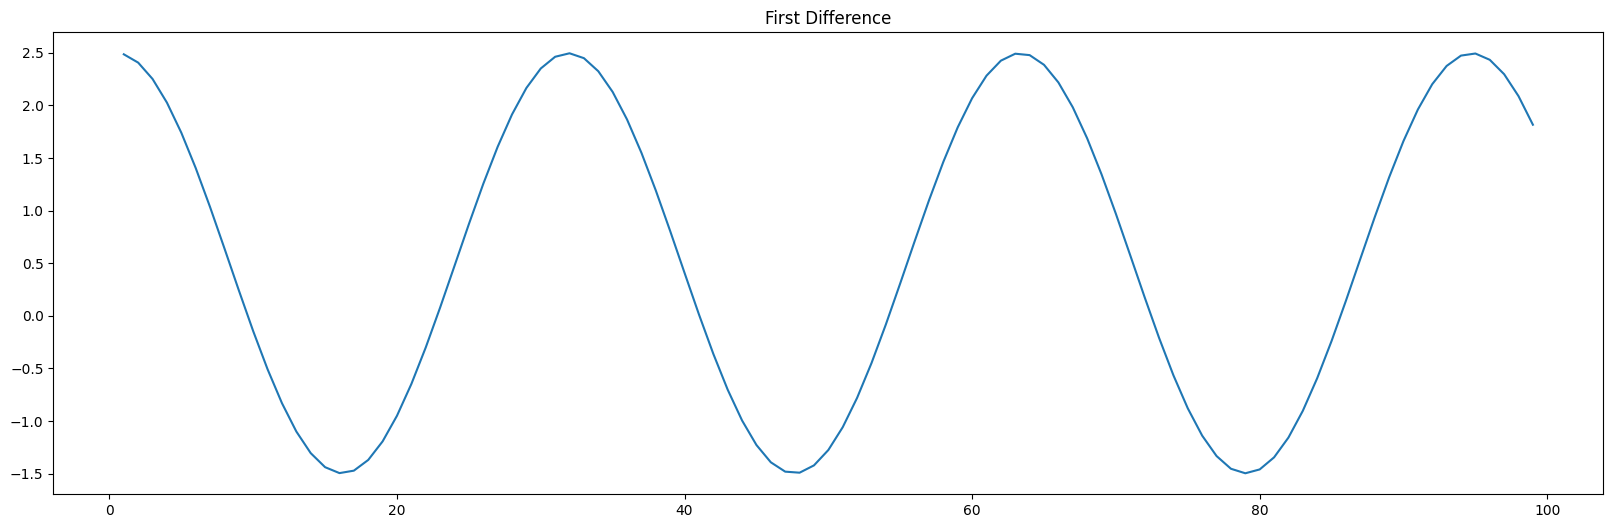

In [ ]:
# first difference
diff_series = series.diff()

plt.figure()
diff_series.plot(title="First Difference")
plt.show()


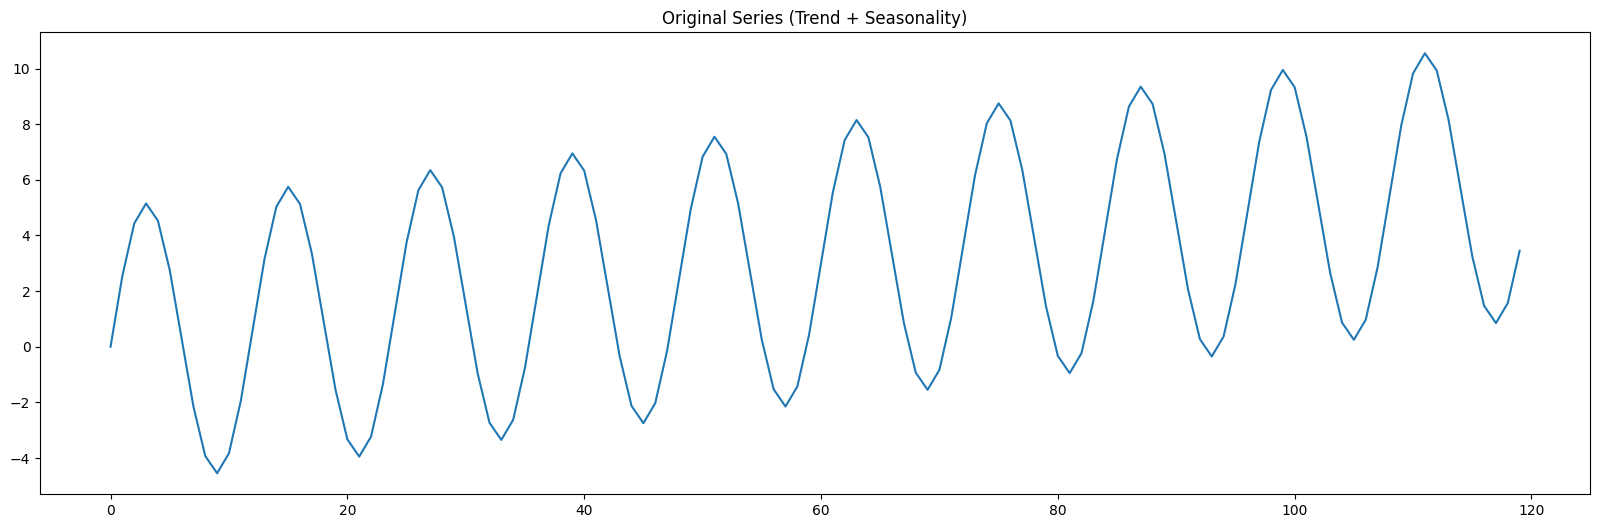

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# time index
t = np.arange(120)

# trend + seasonality
y = 0.05 * t + 5 * np.sin(2 * np.pi * t / 12)

series = pd.Series(y)

series.plot(title="Original Series (Trend + Seasonality)")
plt.show()


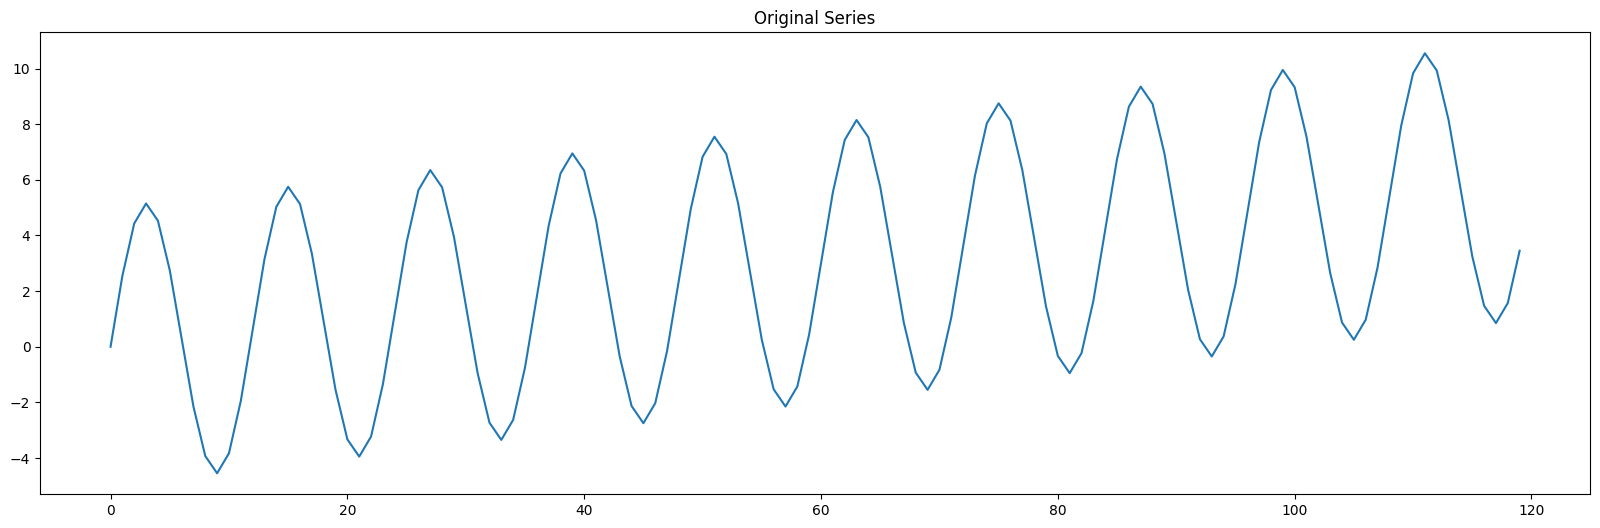

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

t = np.arange(120)
y = 5 * np.sin(2 * np.pi * t / 12) + 0.05 * t   # seasonality + trend

series = pd.Series(y)

series.plot(title="Original Series")
plt.show()


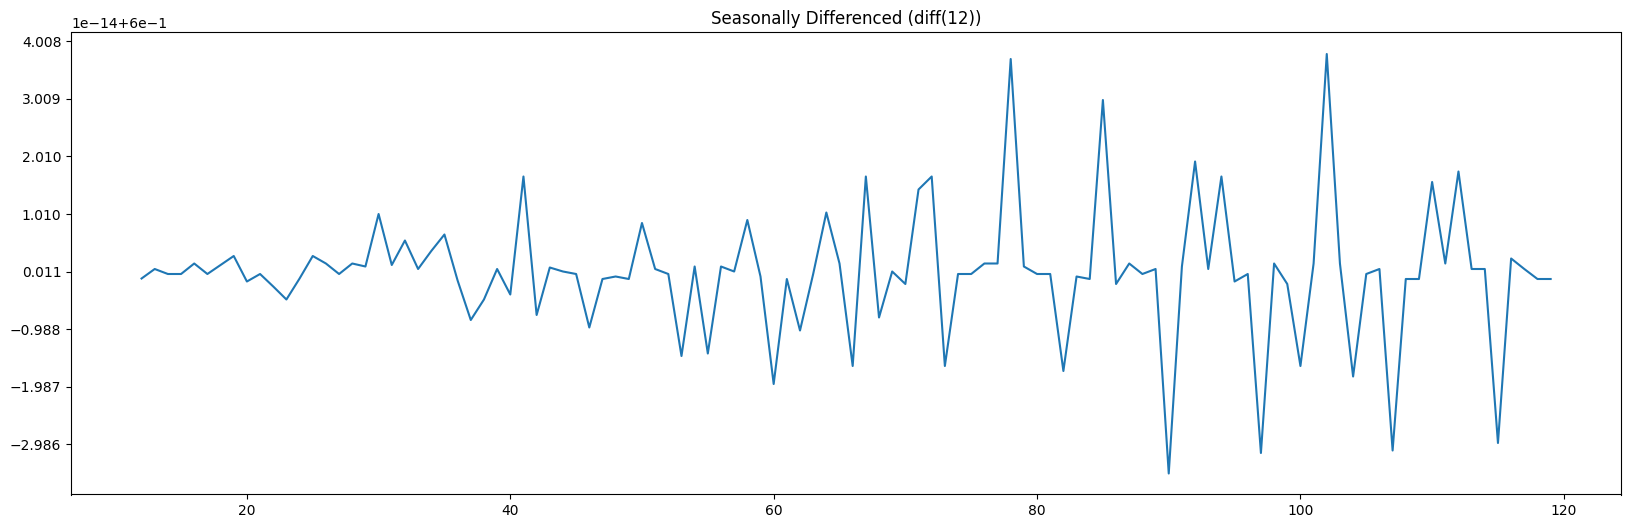

In [ ]:
m = 12
seasonal_diff = series.diff(m)

seasonal_diff.plot(title="Seasonally Differenced (diff(12))")
plt.show()

## Extra Reading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA


In [ ]:
np.random.seed(42)

white_noise = np.random.normal(0, 1, 200)


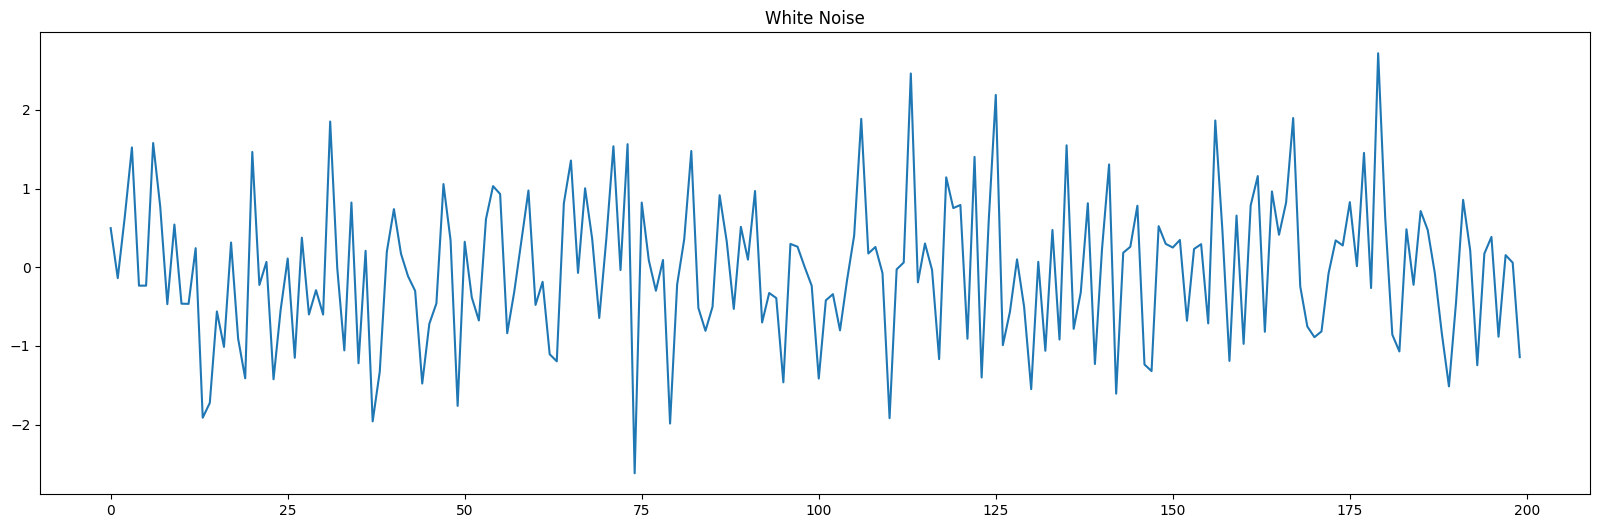

In [ ]:
plt.figure()
plt.plot(white_noise)
plt.title("White Noise")
plt.show()


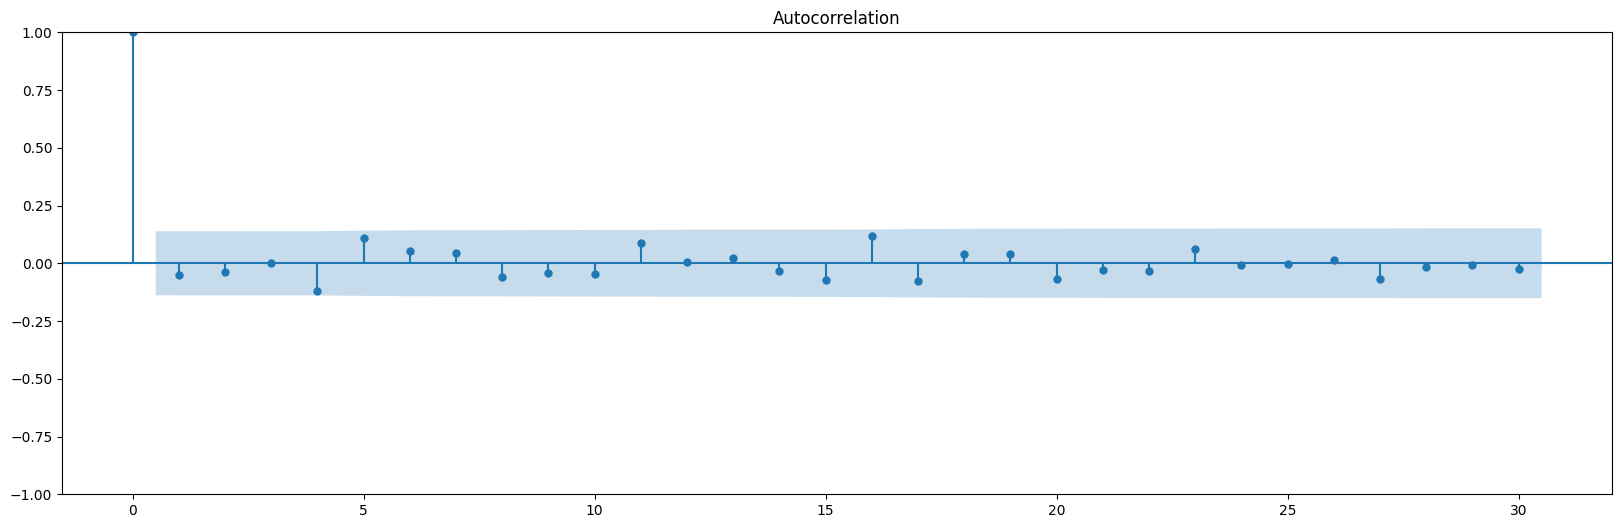

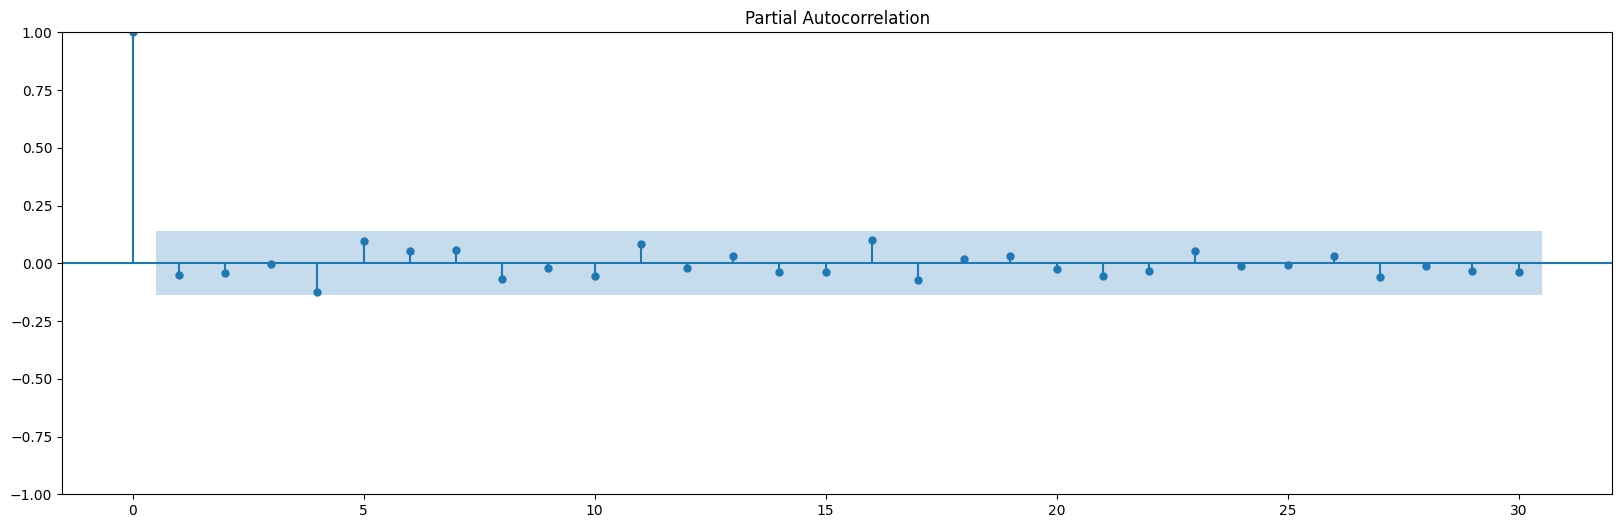

In [ ]:
plot_acf(white_noise, lags=30)
plt.show()

plot_pacf(white_noise, lags=30)
plt.show()


## Random walk

In [ ]:
random_steps = np.random.normal(0, 1, 200)
random_walk = np.cumsum(random_steps)


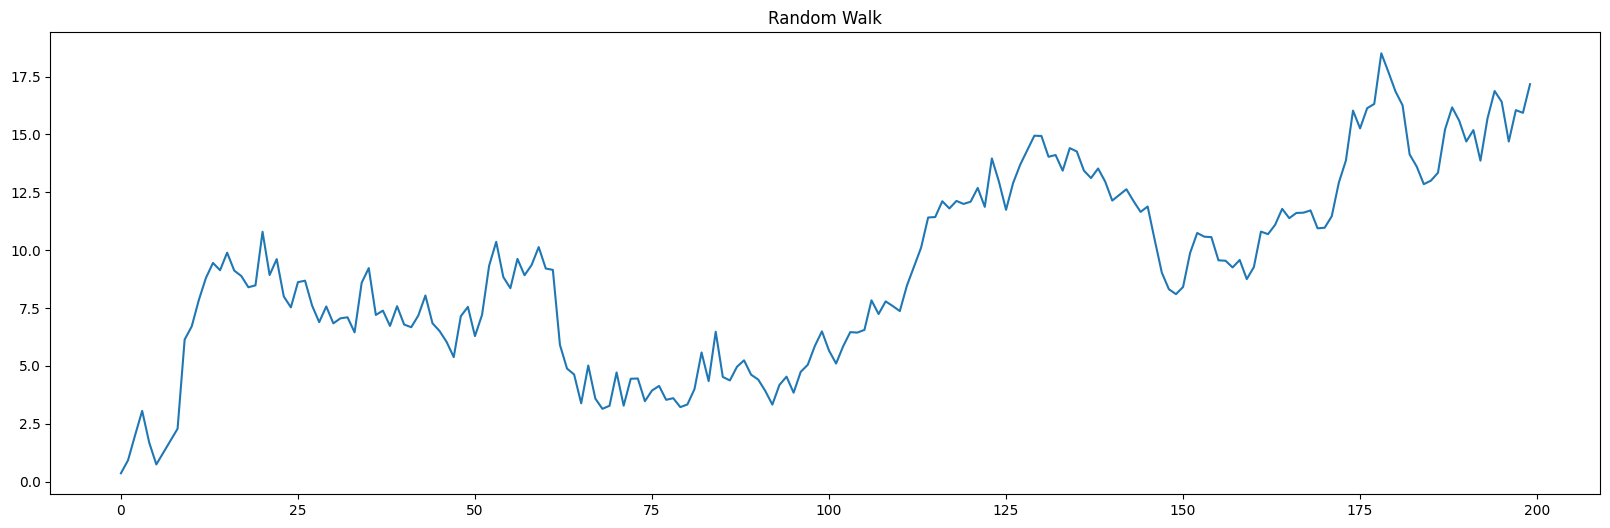

In [ ]:
plt.figure()
plt.plot(random_walk)
plt.title("Random Walk")
plt.show()


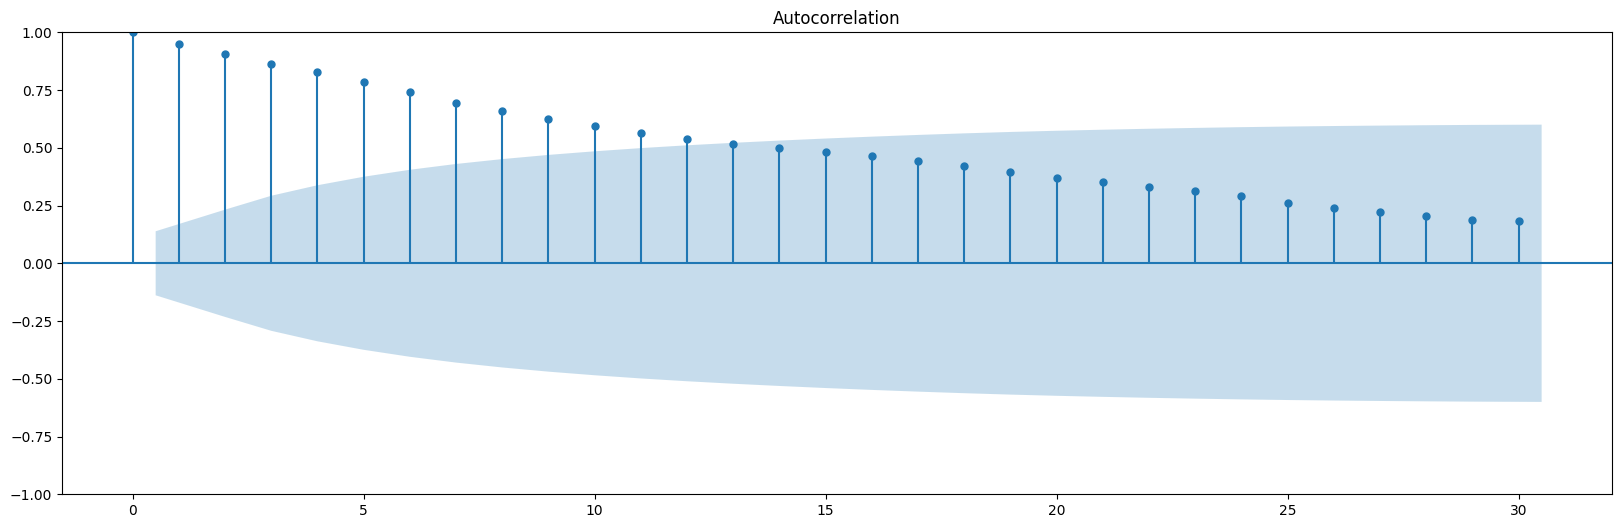

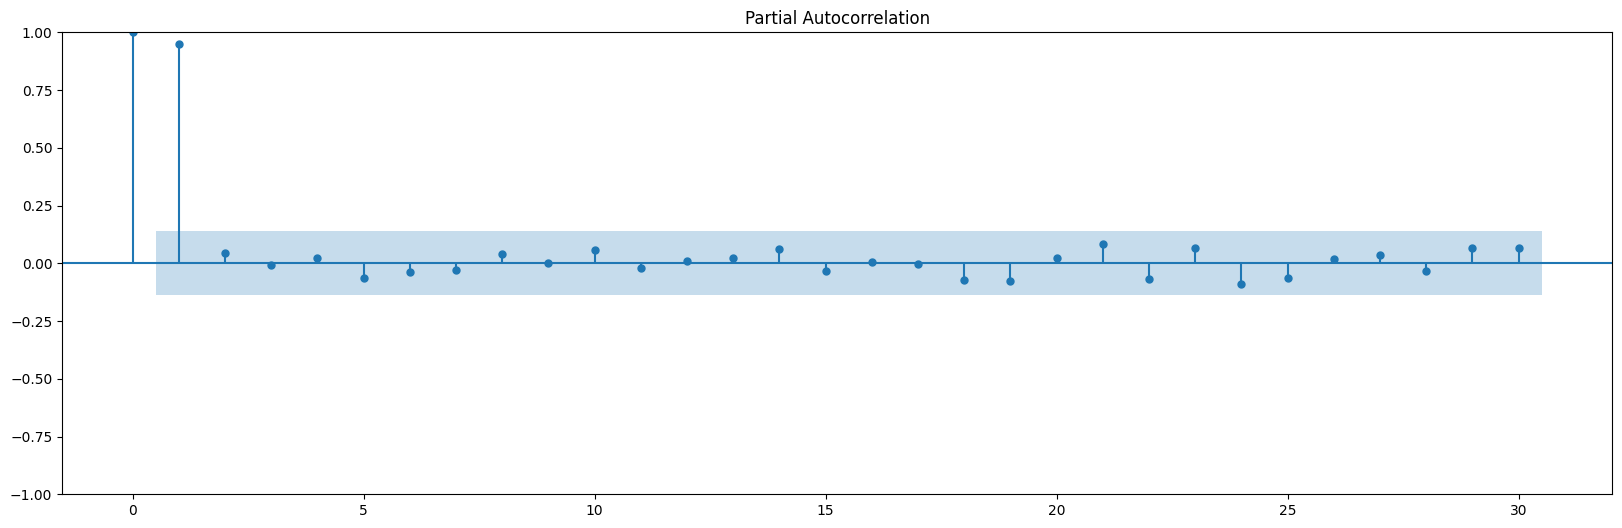

In [ ]:
plot_acf(random_walk, lags=30)
plt.show()

plot_pacf(random_walk, lags=30)
plt.show()


In [ ]:
diff_rw = np.diff(random_walk)


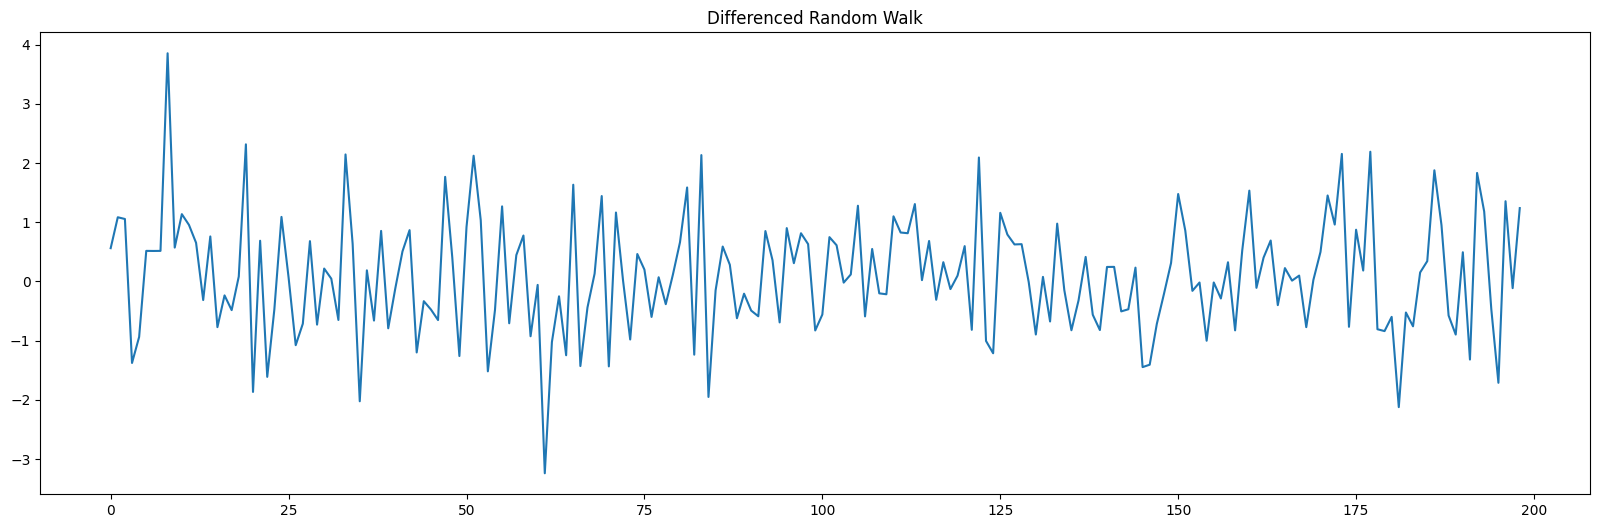

In [ ]:
plt.figure()
plt.plot(diff_rw)
plt.title("Differenced Random Walk")
plt.show()


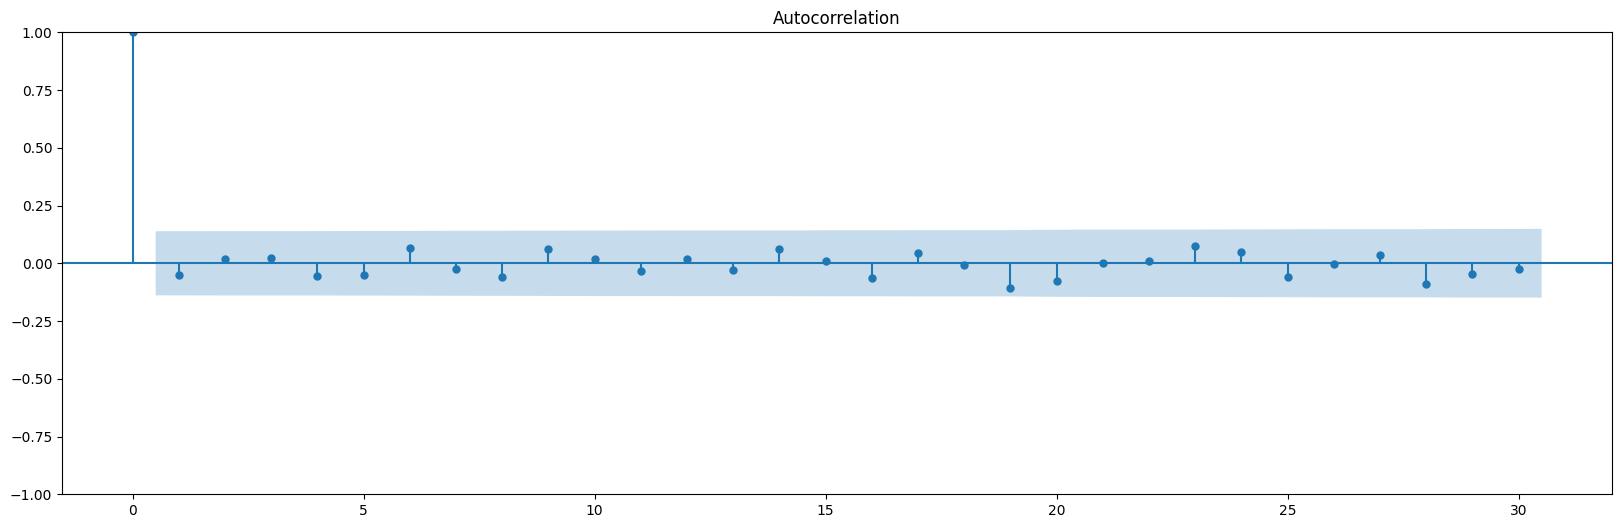

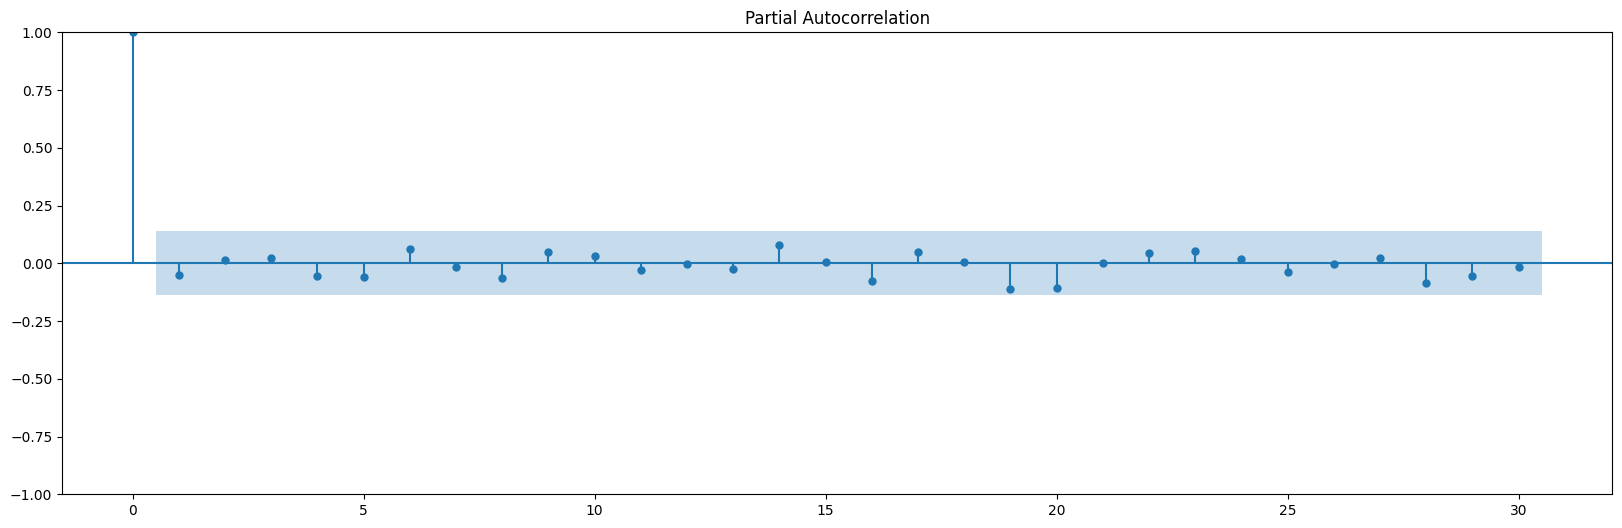

In [ ]:
plot_acf(diff_rw, lags=30)
plt.show()

plot_pacf(diff_rw, lags=30)
plt.show()


In [ ]:
data = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
)

data["Month"] = pd.to_datetime(data["Month"])
data.set_index("Month", inplace=True)

series = data["Passengers"]


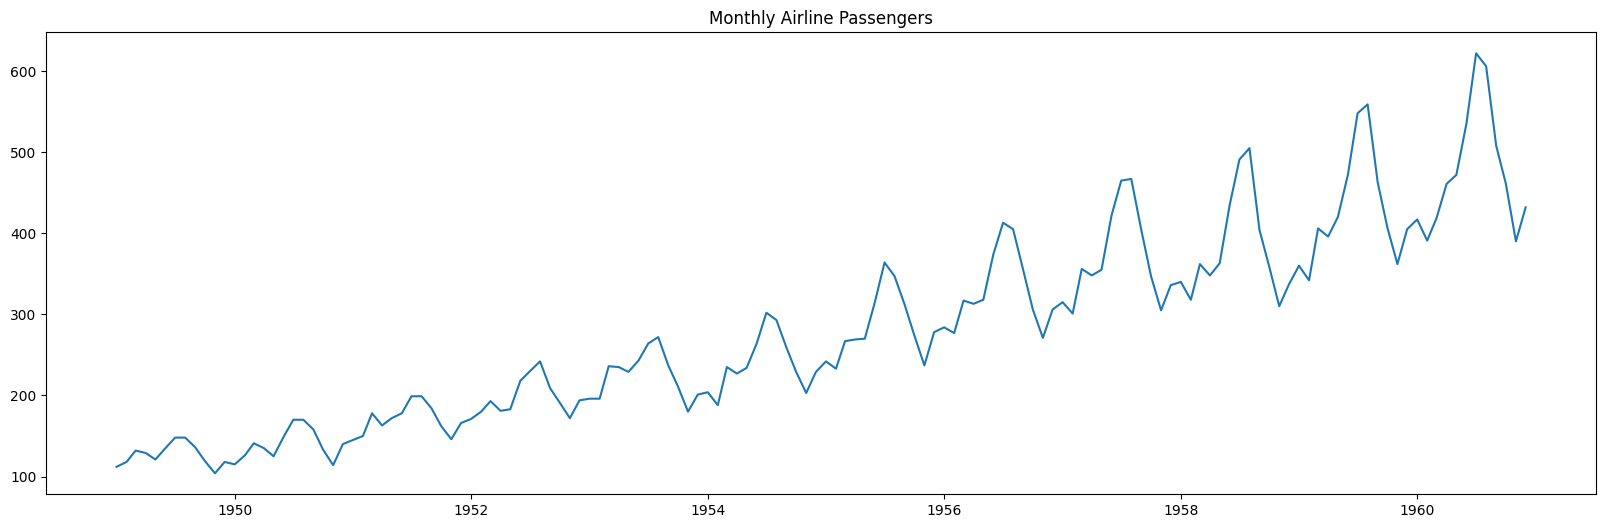

In [ ]:
plt.figure()
plt.plot(series)
plt.title("Monthly Airline Passengers")
plt.show()


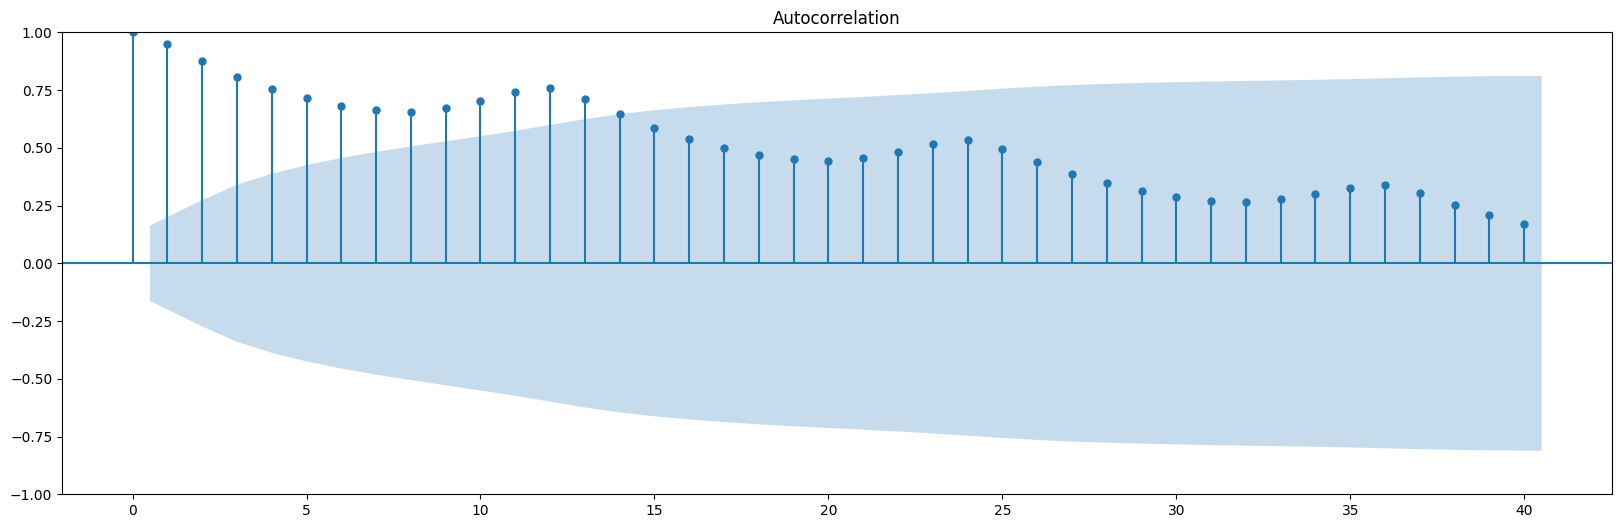

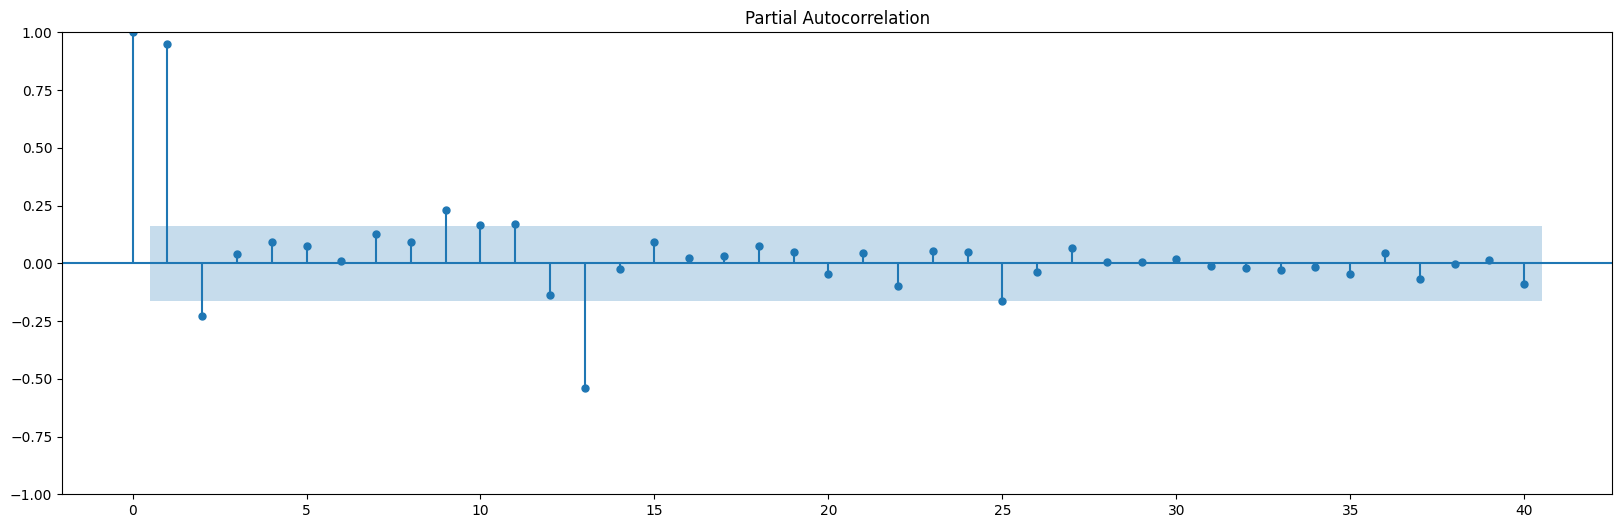

In [ ]:
plot_acf(series, lags=40)
plt.show()

plot_pacf(series, lags=40)
plt.show()


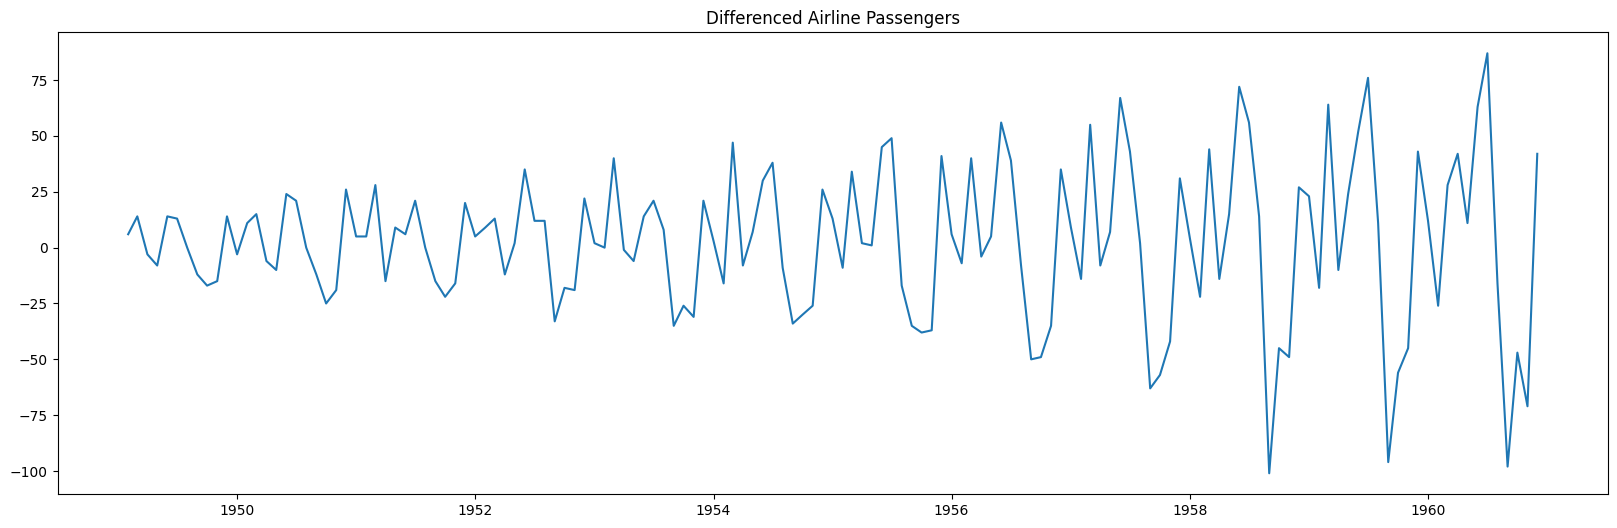

In [ ]:
diff_series = series.diff().dropna()

plt.figure()
plt.plot(diff_series)
plt.title("Differenced Airline Passengers")
plt.show()


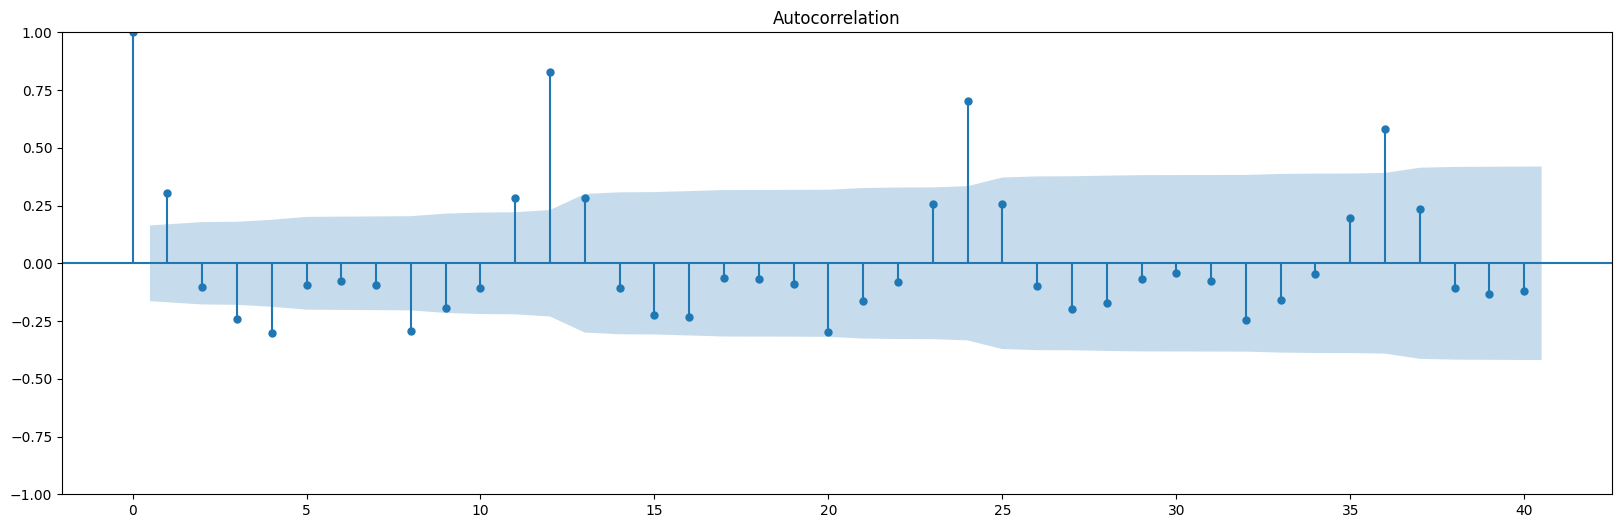

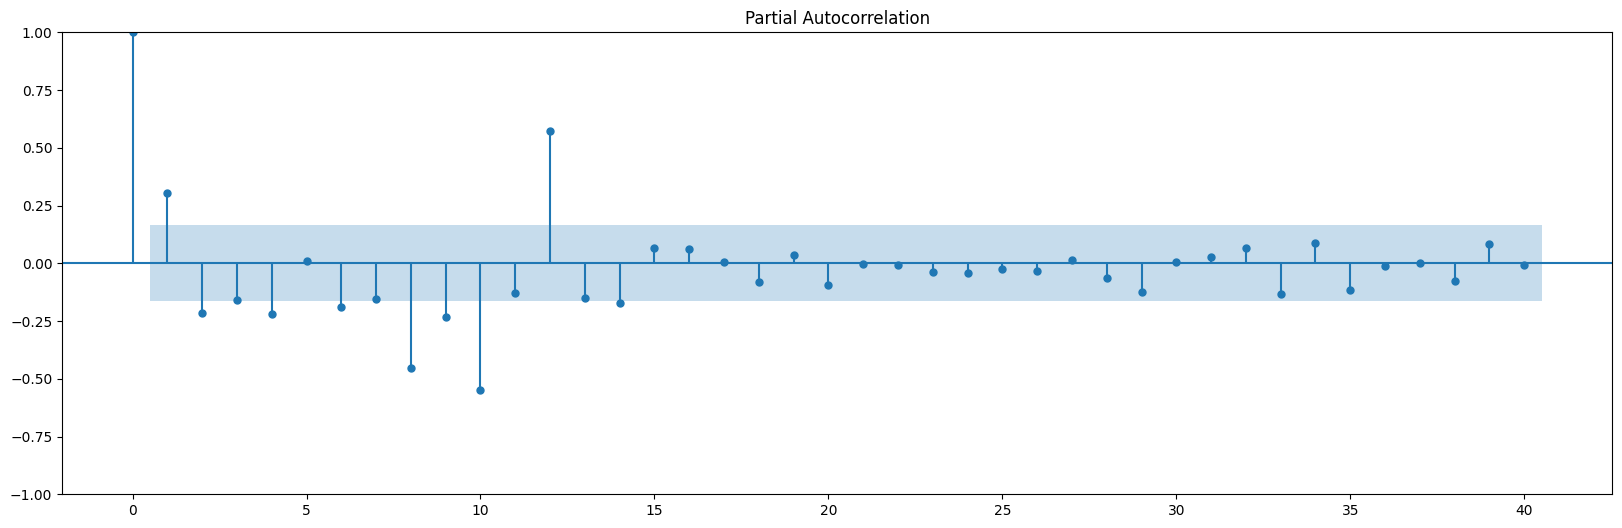

In [ ]:
plot_acf(diff_series, lags=40)
plt.show()

plot_pacf(diff_series, lags=40)
plt.show()


In [ ]:
mobile_sales.Sales.head()

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00


In [ ]:
mobile_sales.Sales

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00
...,...
2018-09-01,13838.00
2018-10-01,15351.00
2018-11-01,15615.00


In [ ]:
mobile_sales.Sales.shift(1).head(10)

,Sales
DATE,
2001-01-01,NaN
2001-02-01,6802.44
2001-03-01,6802.44
2001-04-01,7332.00
2001-05-01,7332.00
2001-06-01,8240.00
2001-07-01,8104.00
2001-08-01,7813.00
2001-09-01,8279.00


In [ ]:
lag = 3

np.corrcoef(mobile_sales.Sales[lag:], mobile_sales.Sales.shift(lag)[lag:])[0][1]

np.float64(0.72747799932532)

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

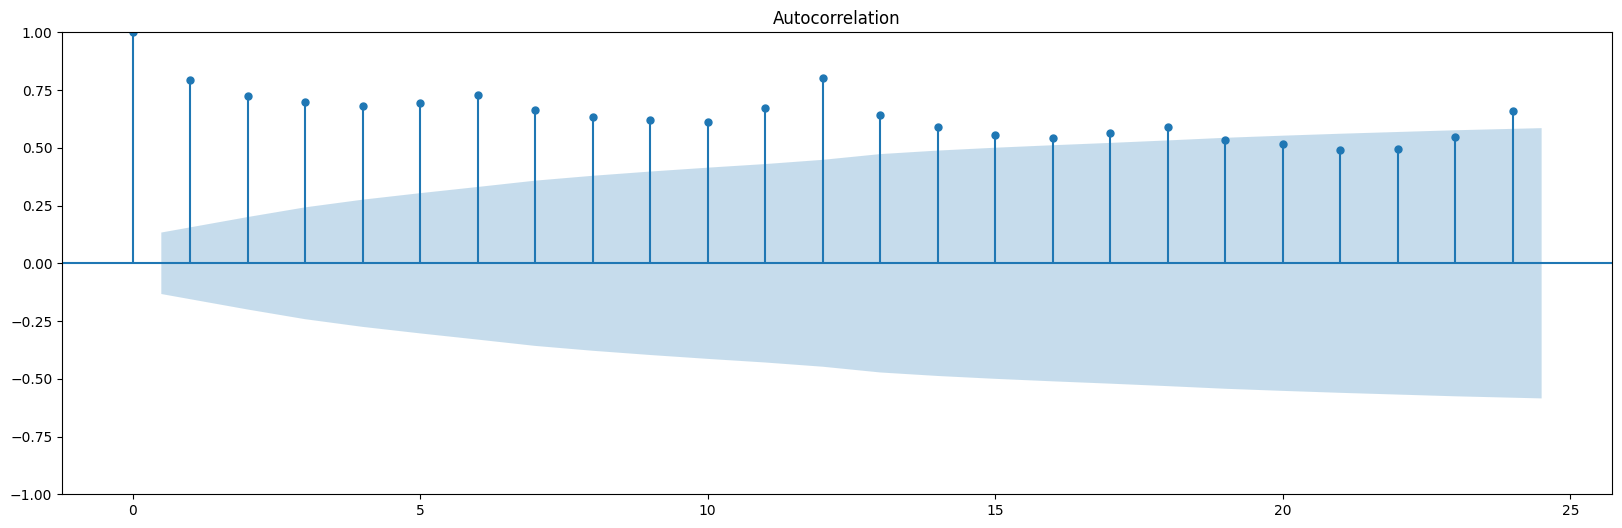

In [ ]:
plot_acf(mobile_sales.Sales);

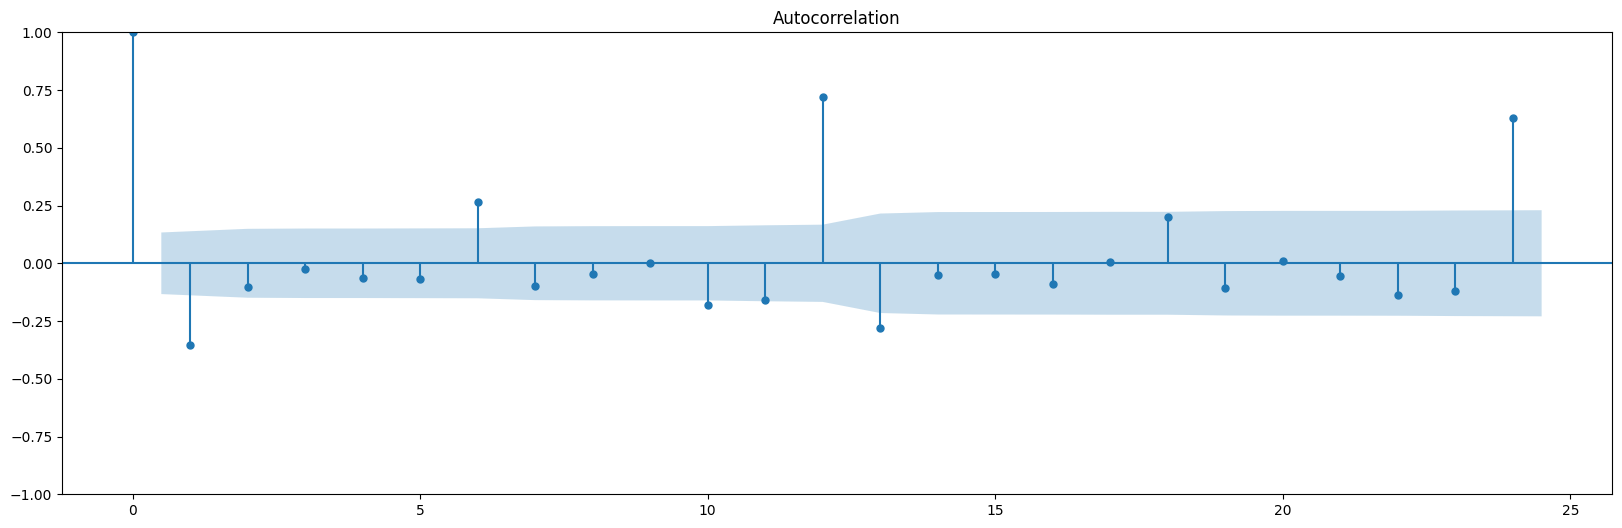

In [ ]:
plot_acf(mobile_sales.Sales.diff().dropna());

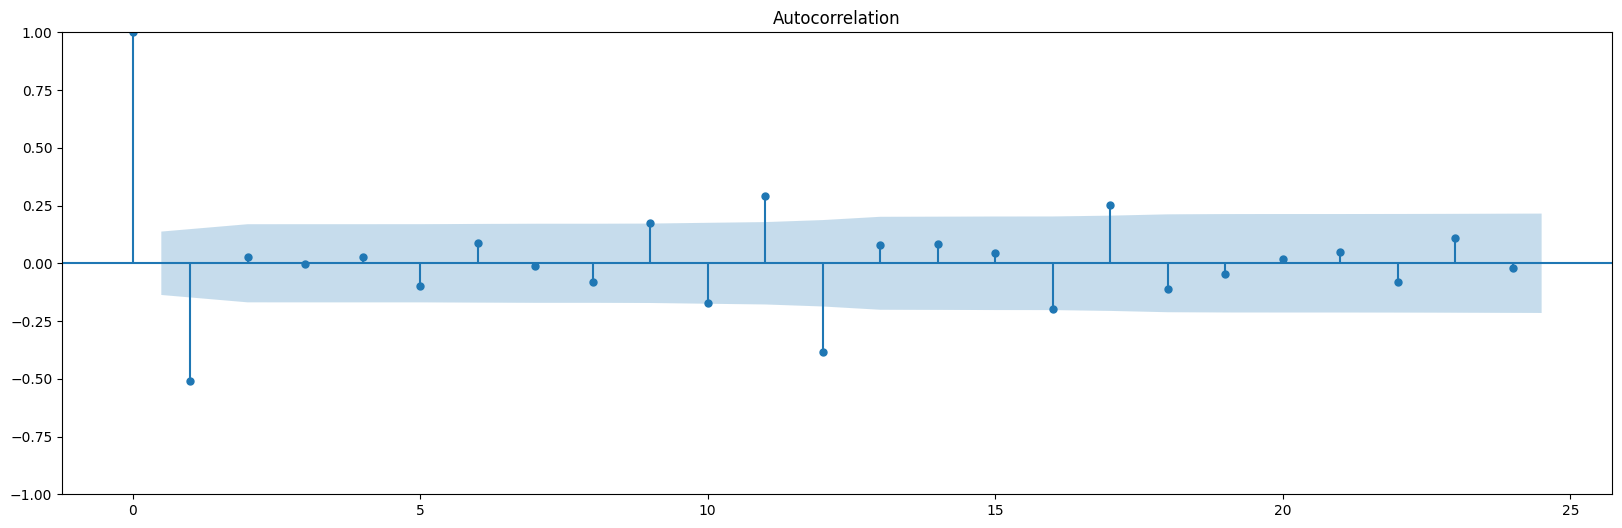

In [ ]:
plot_acf(mobile_sales.Sales.diff().diff(12).dropna());

## PACF

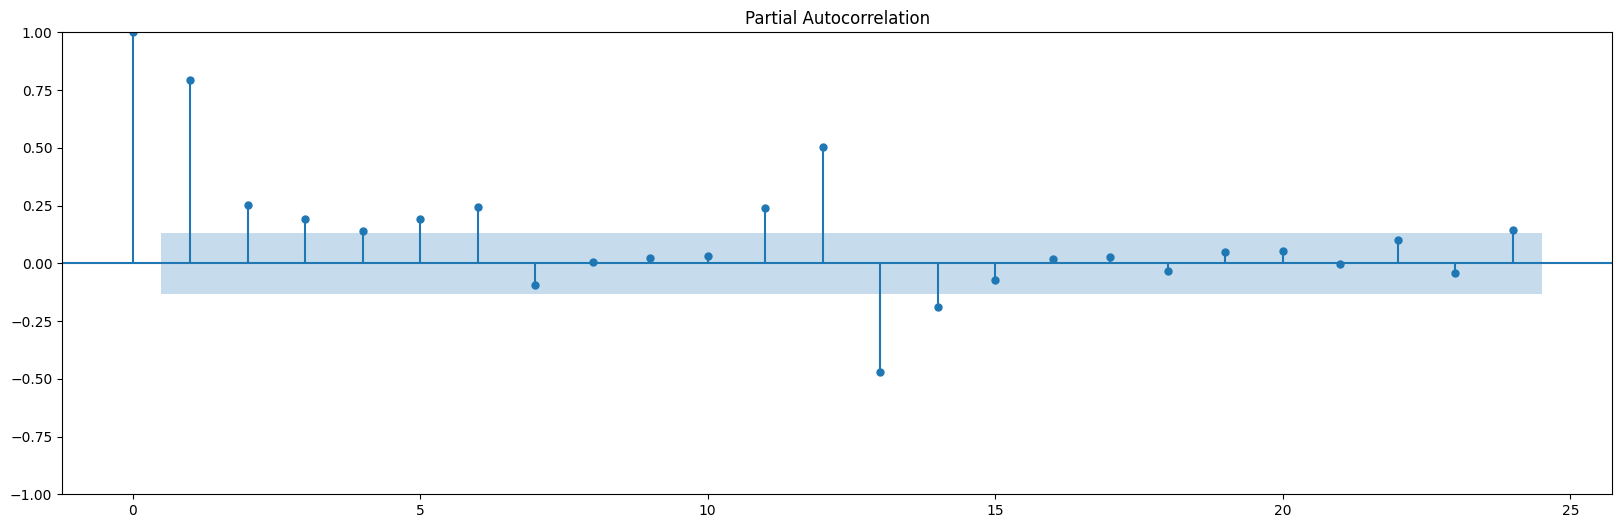

In [ ]:
plot_pacf(mobile_sales.Sales);

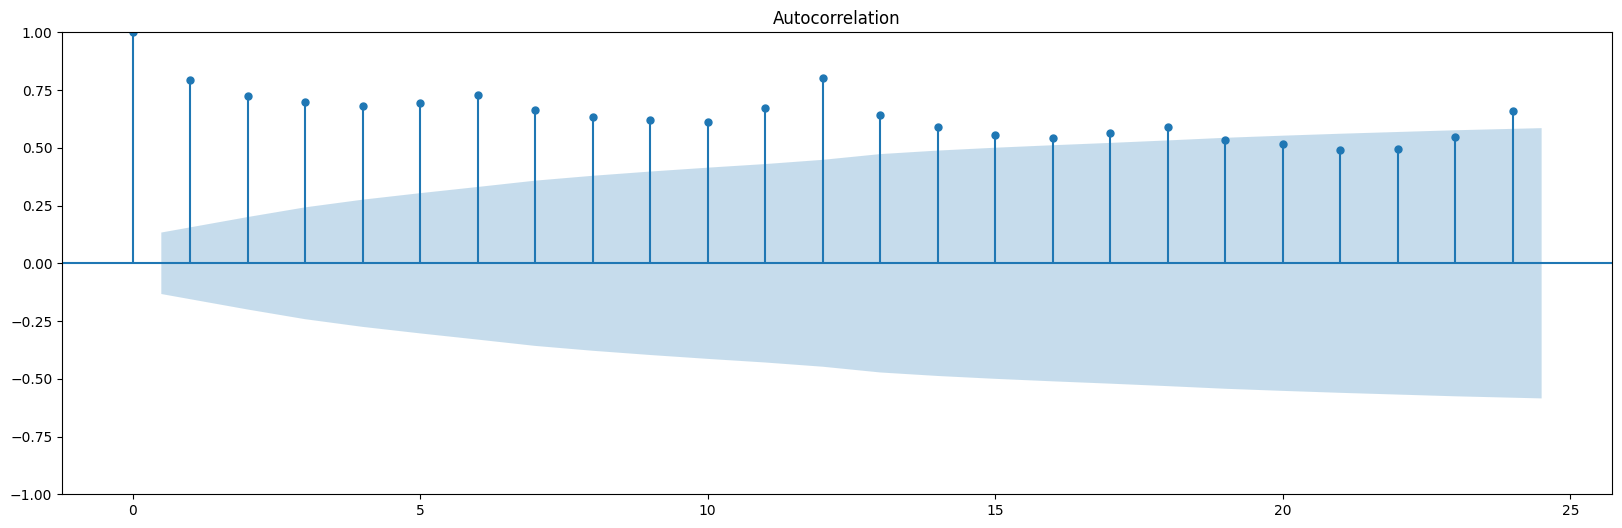

In [ ]:
plot_acf(mobile_sales.Sales);

## AR(1) in code

<Axes: xlabel='DATE'>

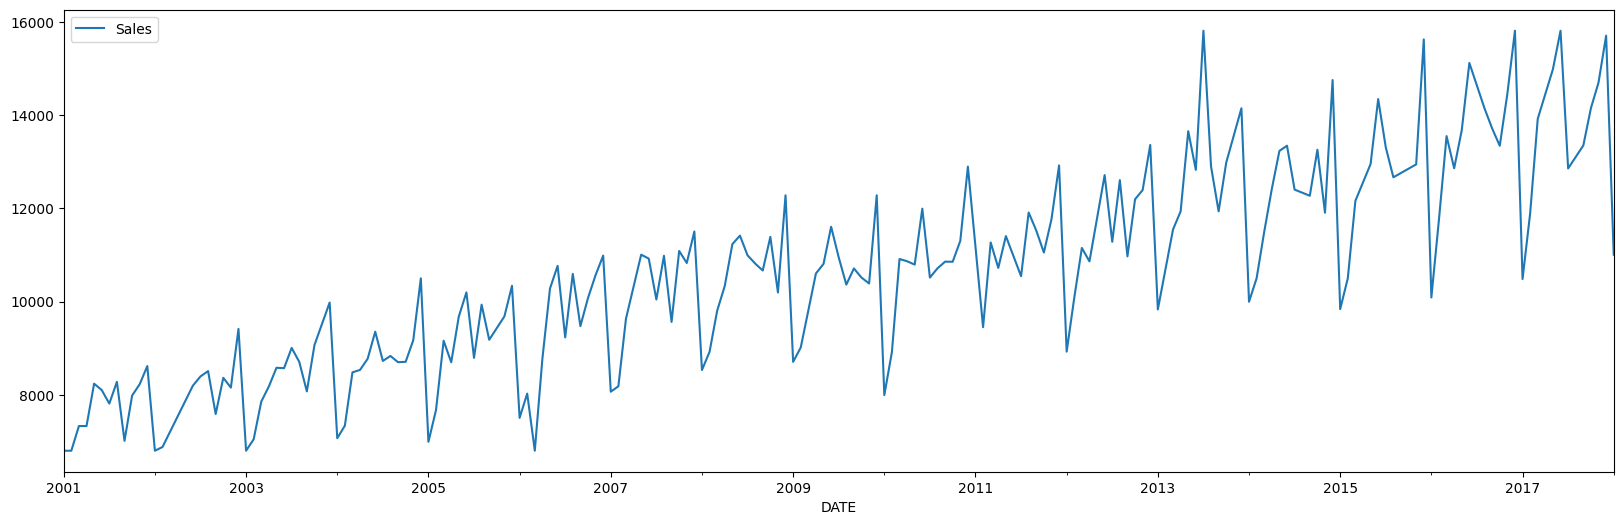

In [ ]:
train_x.plot()

In [ ]:
def adf_test(dataset):
   pvalue = sm.tsa.stattools.adfuller(dataset)[1]
   if pvalue <= 0.05:
      print('Sequence is stationary')
   else:
      print('Sequence is not stationary')

In [ ]:
adf_test(train_x.Sales)

Sequence is not stationary


In [ ]:
train_x_st = train_x.copy()

In [ ]:
train_x_st.Sales = train_x_st.Sales.diff(1)

In [ ]:
train_x_st.dropna(inplace=True)

<Axes: xlabel='DATE'>

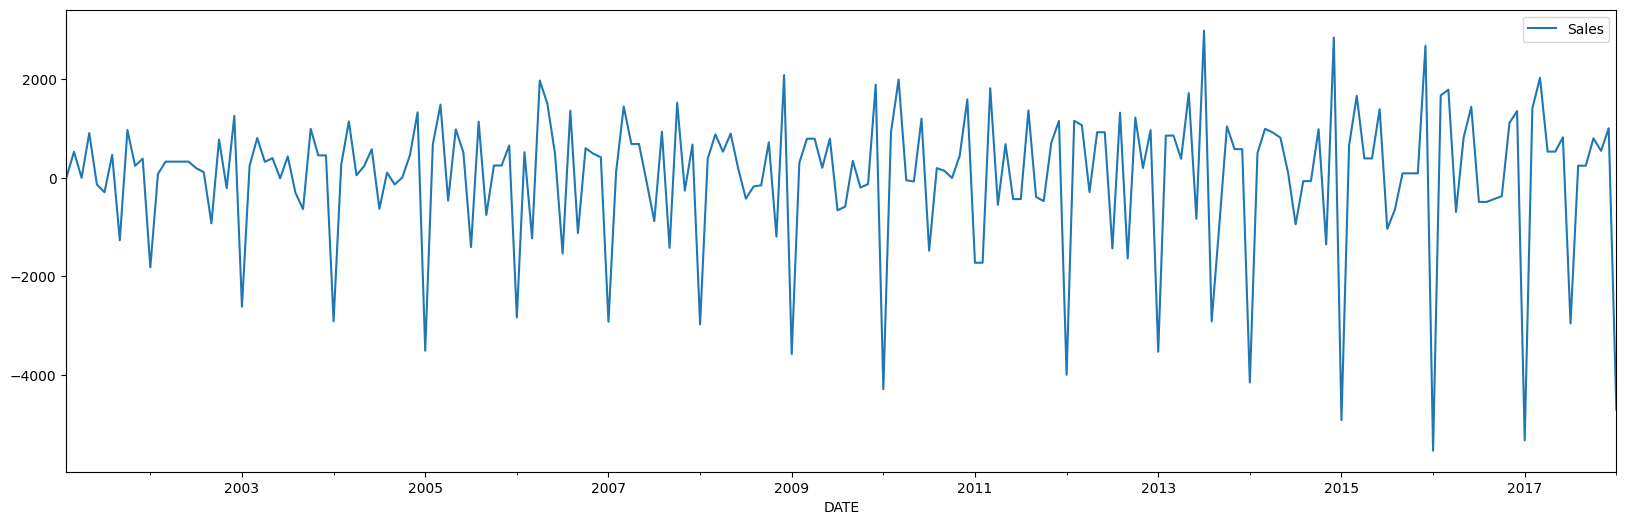

In [ ]:
train_x_st.plot()

In [ ]:
adf_test(train_x_st.Sales)

Sequence is stationary


In [ ]:
import statsmodels as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model = SARIMAX(train_x_st.Sales, order = (1,0,0) )

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
model = model.fit(disp=False)

In [ ]:
test_x['pred'] = model.forecast(steps=12)

In [ ]:
test_x

,Sales,pred
DATE,,
2018-02-01,11852.0,1728.700558
2018-03-01,14123.0,-635.966295
2018-04-01,13360.0,233.963671
2018-05-01,15576.0,-86.072170
2018-06-01,15809.4,31.664824
2018-07-01,14080.0,-11.649074
2018-08-01,15697.0,4.285542
2018-09-01,13838.0,-1.576595
2018-10-01,15351.0,0.580009


In [ ]:

# Integrate !!

test_x['pred'] = test_x['pred'].cumsum() +  train_x.Sales[-1]

/tmp/ipython-input-2463184693.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_x['pred'] = test_x['pred'].cumsum() +  train_x.Sales[-1]


In [ ]:
test_x['pred']

,pred
DATE,
2018-02-01,12733.700558
2018-03-01,12097.734263
2018-04-01,12331.697934
2018-05-01,12245.625763
2018-06-01,12277.290588
2018-07-01,12265.641514
2018-08-01,12269.927055
2018-09-01,12268.350461
2018-10-01,12268.930469


<Axes: xlabel='DATE'>

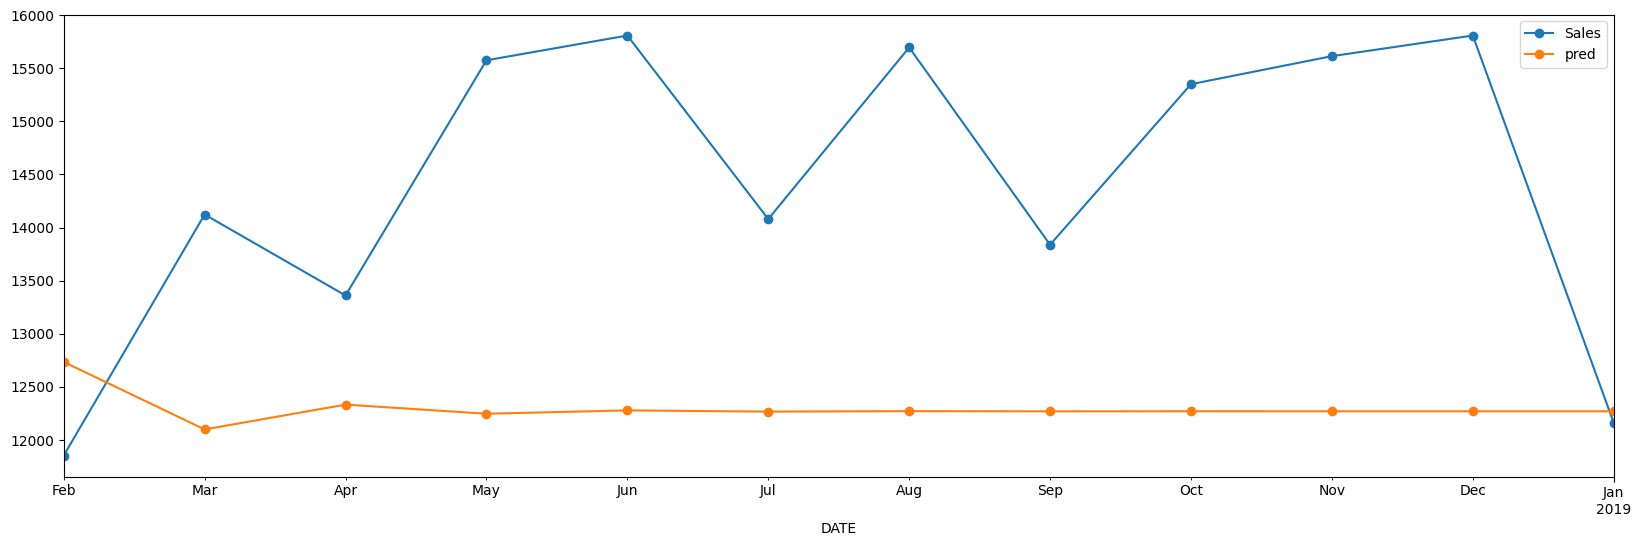

In [ ]:
test_x.plot(style='-o')

In [ ]:
performance(test_x['Sales'], test_x['pred'])

MAE : 2307.213
RMSE : 2585.999
MAPE: 0.153


## How to select order

> **GUIDE**
> - **If the ACF plot gradually decreases, and PACF plot suddenly cuts of after lag k, then we can consider AR model with order p=k**
> - Here, there is also some seasonality which we did not remove, maybe there is also some quaterly seasonality, which is why the above rule does not give a clear guess -- Human judgement call needed here

In [ ]:
model = SARIMAX(train_x_st.Sales, order=(3, 0, 0))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


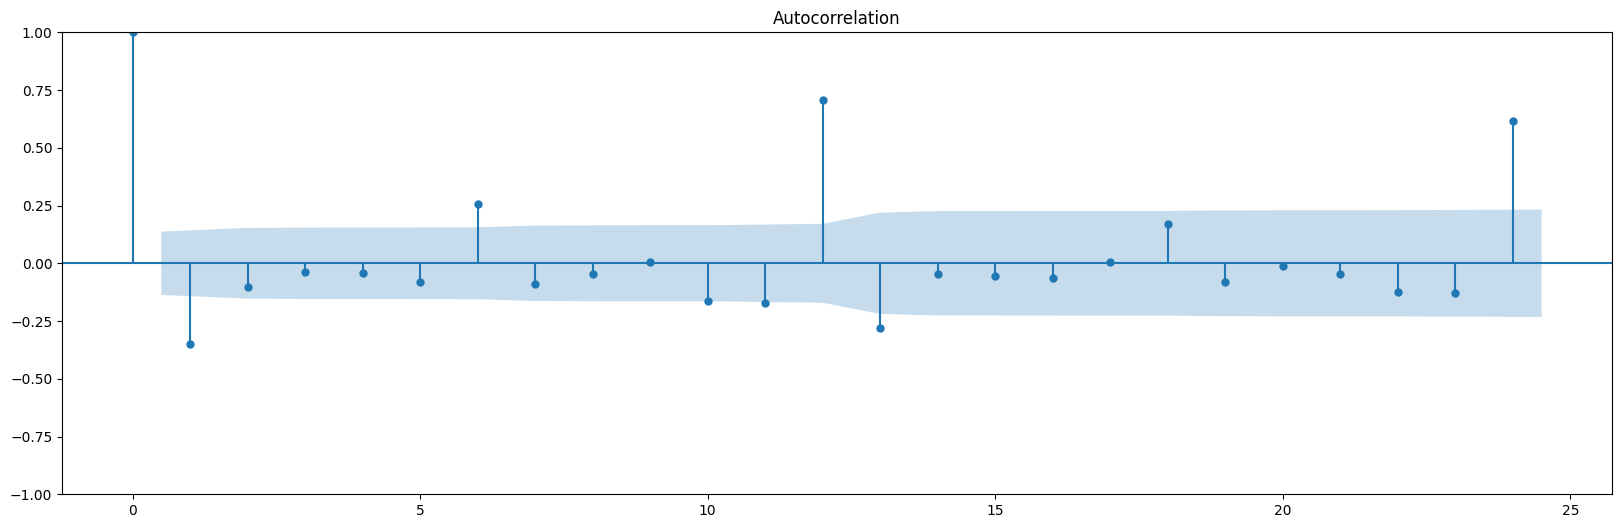

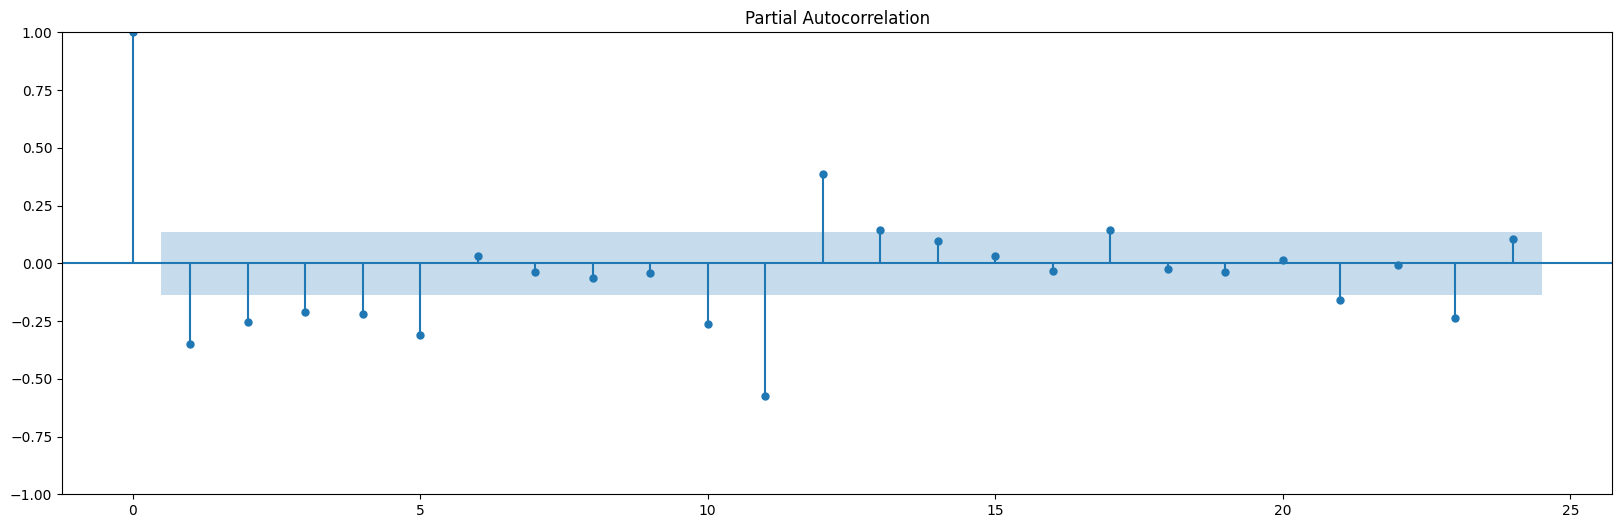

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

plot_acf(train_x_st.Sales);
plot_pacf(train_x_st.Sales);

In [ ]:
test_x['pred']

,pred
DATE,
2018-02-01,1968.692138
2018-03-01,499.641046
2018-04-01,56.459859
2018-05-01,-659.381153
2018-06-01,212.947264
2018-07-01,122.413091
2018-08-01,4.157691
2018-09-01,-95.907466
2018-10-01,21.310213


/tmp/ipython-input-2374034299.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]


MAE : 1647.061
RMSE : 1890.003
MAPE: 0.11


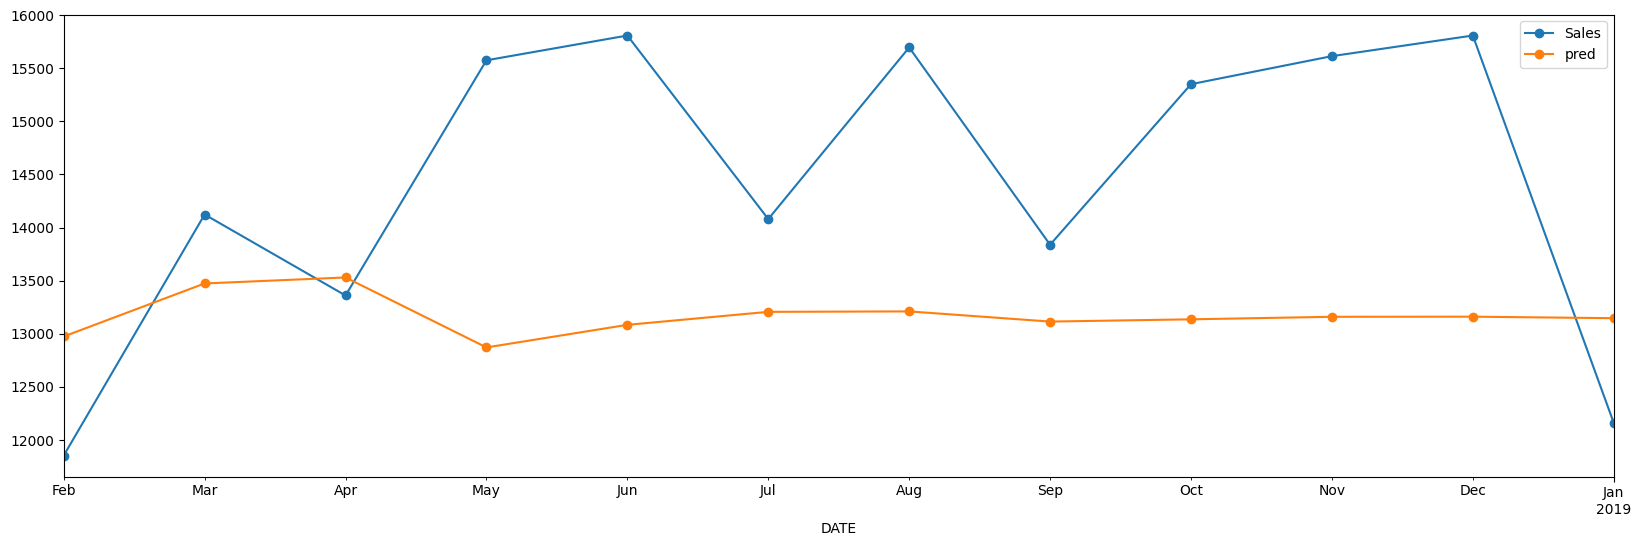

In [ ]:


# Integrating the trend back!
test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]

# Plotting
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

In [ ]:

performance(test_x['Sales'], test_x['pred'])

MAE : 1647.061
RMSE : 1890.003
MAPE: 0.11


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-4117859150.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]


MAE : 1337.232
RMSE : 1541.108
MAPE: 0.091


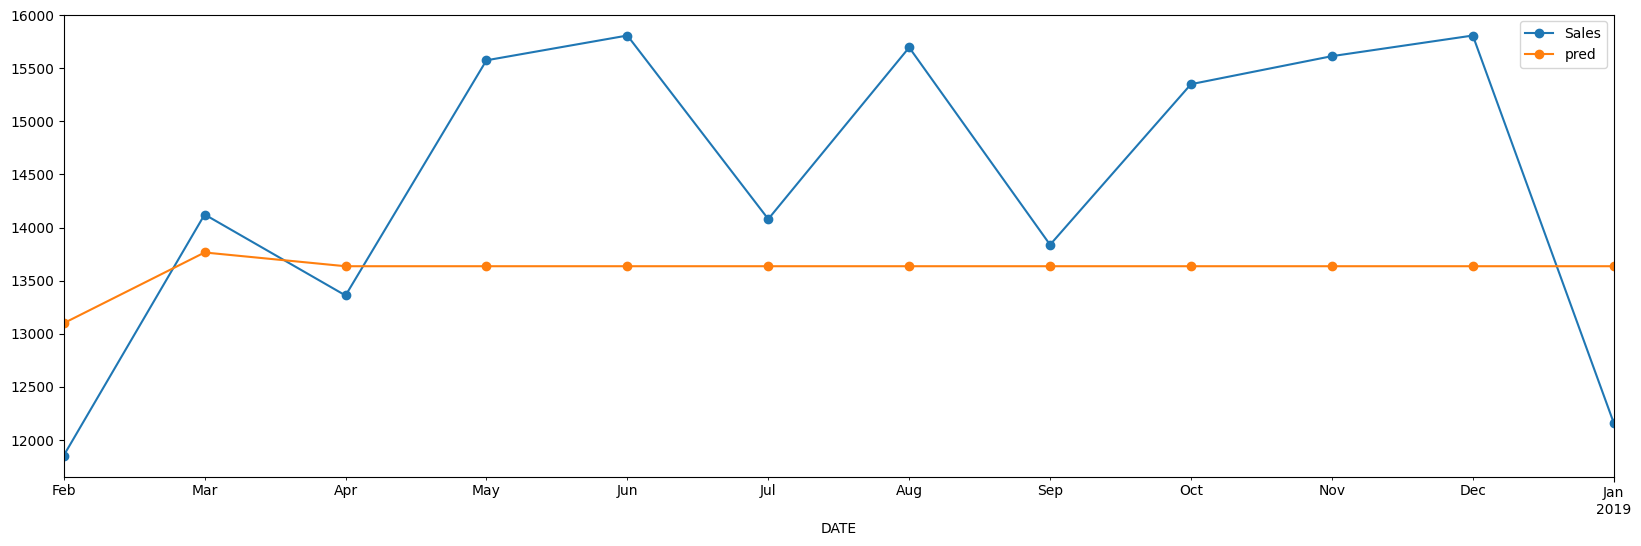

In [ ]:
model = SARIMAX(train_x_st.Sales, order=(0, 0, 3))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)

test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]

test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-1656089515.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]


MAE : 1298.692
RMSE : 1521.165
MAPE: 0.088


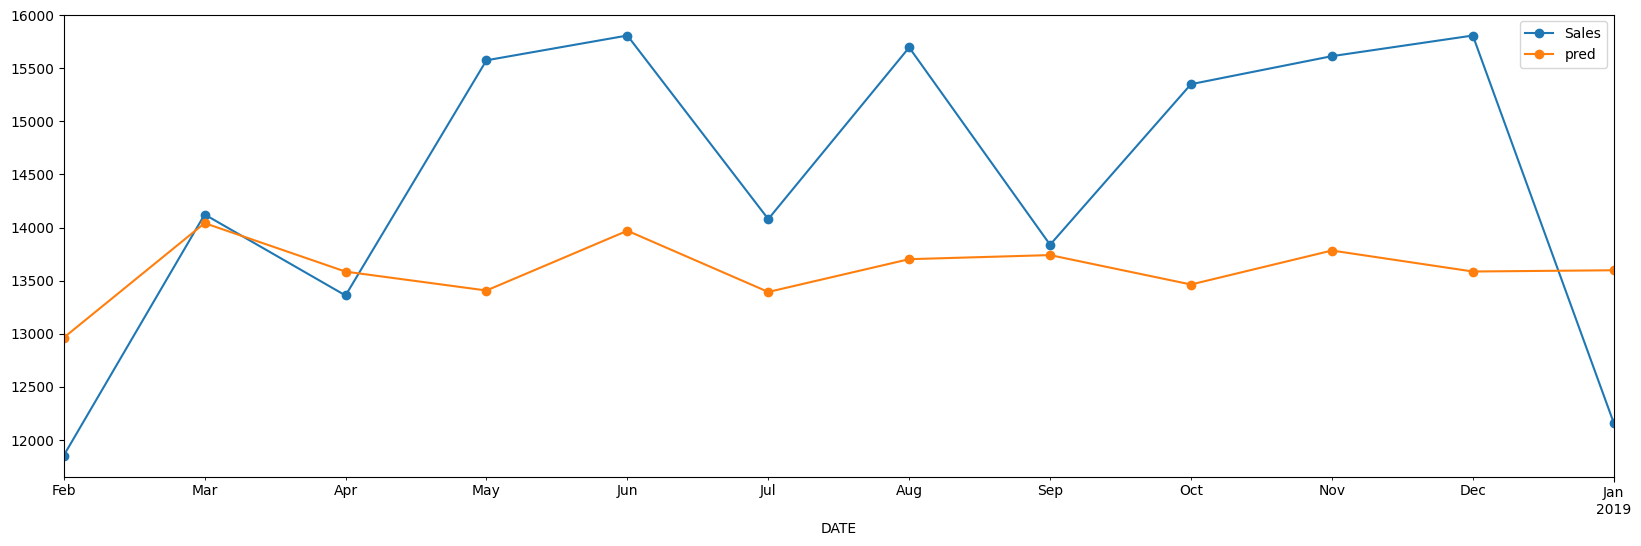

In [ ]:
model = SARIMAX(train_x_st.Sales, order=(3, 0, 3))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)

## Integration
test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]

test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 1307.143
RMSE : 1528.883
MAPE: 0.088


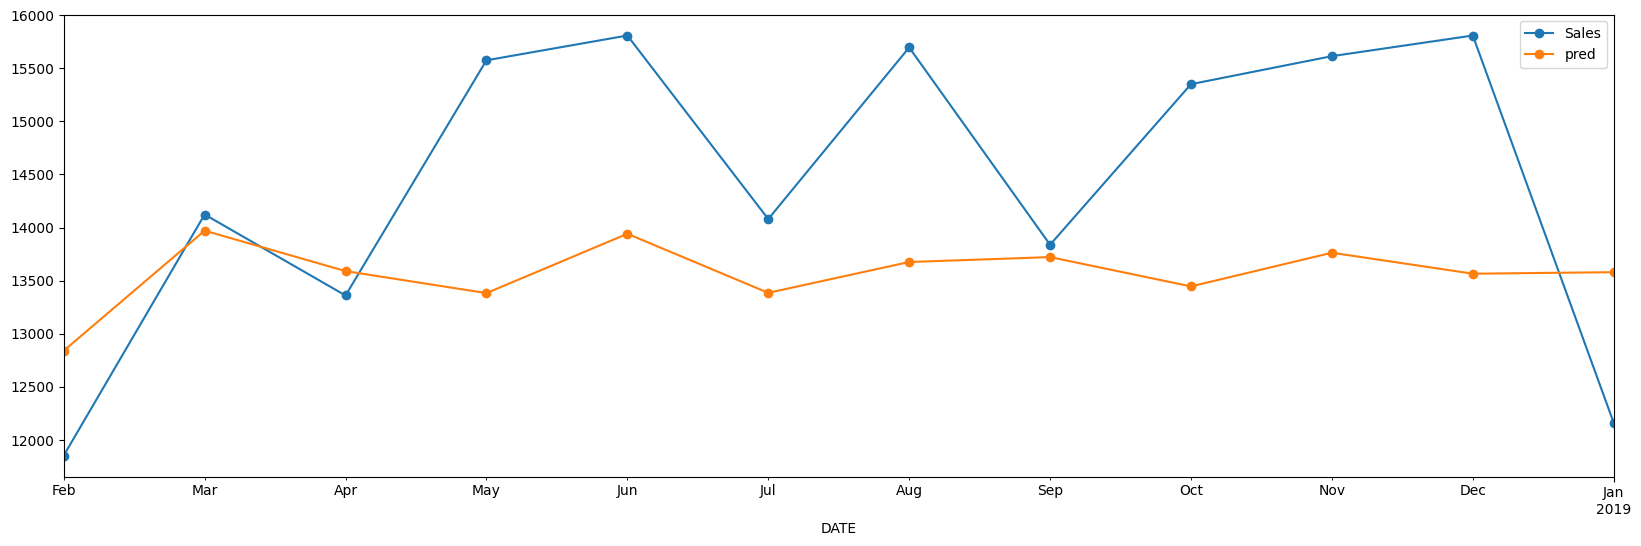

In [ ]:
## AR I MA


from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train_x.Sales, order=(3, 1, 3))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

## SARIMA model

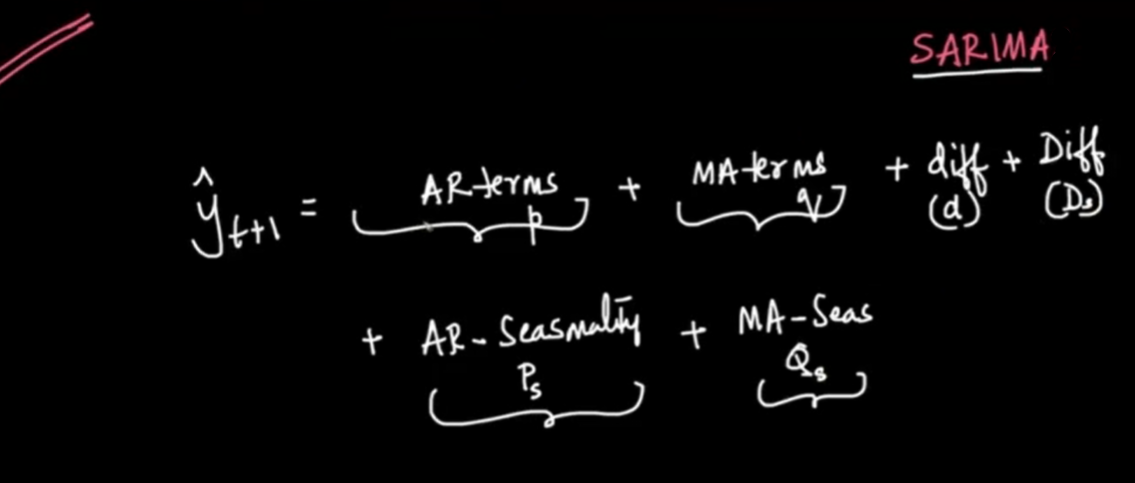

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 536.465
RMSE : 623.233
MAPE: 0.037


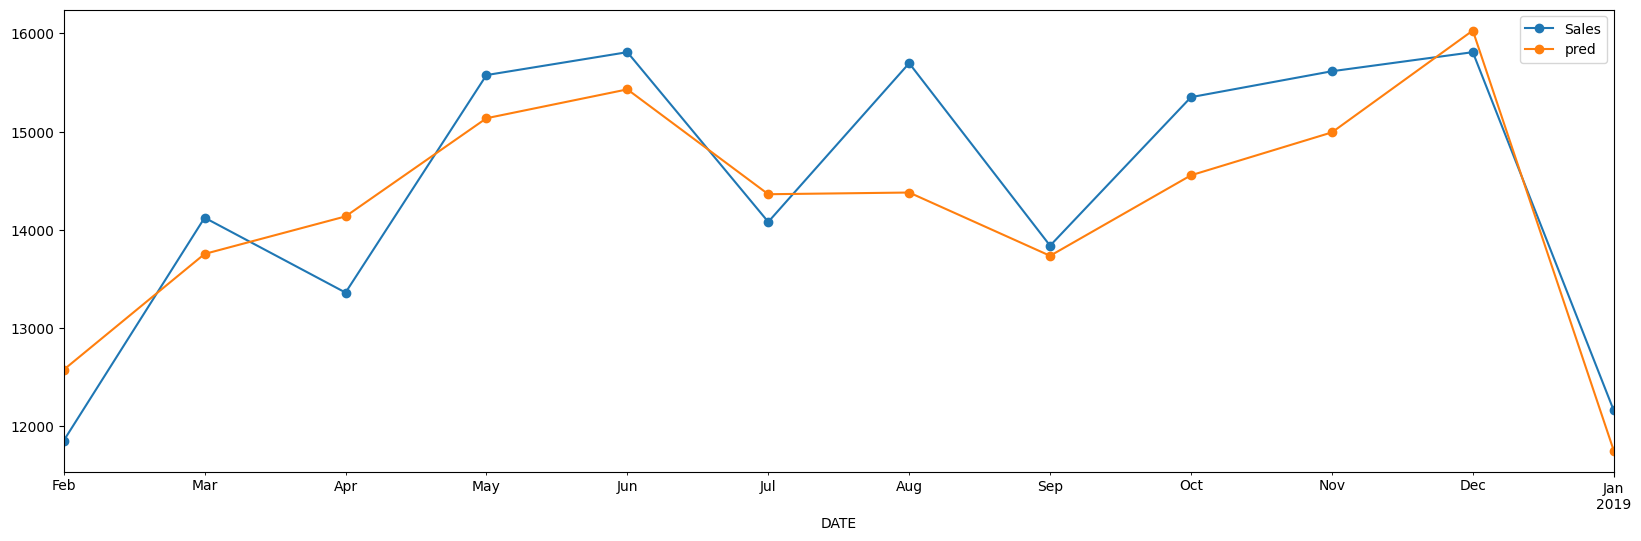

In [ ]:
model = SARIMAX(train_x.Sales, order=(3, 1, 3), seasonal_order=(1,1,1,12))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

## SARIMAX